## Model Loading

In [33]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20260128_122753/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-Regularization2/50/20260202_173939/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3/50/20260202_211809/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3/50/20260204_102702/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3_2/50/20260204_104421/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3_2/50/20260204_104421/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3_2/50/20260204_120940/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_142616/best_joint.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_151621/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_171211/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_171645/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_232352/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_234113/best.pt"
ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260206_013104/best.pt"

#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20260128_122753/best_joint.pt"
##joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-Regularization2/50/20260202_173939/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3/50/20260202_211809/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3/50/20260204_102702/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3_2/50/20260204_104421/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3_2/50/20260204_104421/best_joint.pt"
#joint_ckpt_pretrain_path ="/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3_2/50/20260204_120940/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_142616/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_151621/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_171211/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_171645/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_232352/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260205_234113/best_joint.pt"
joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.02_description-Regularization3_3/50/20260206_013104/best_joint.pt"
ckpt_path = joint_ckpt_pretrain_path

#target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20260128_122753/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260128_122753.pt"
target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3/50/20260202_211809/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260202_211809.pt"
# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.2, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.2, inplace=False)
      (q_proj_list): ModuleLis

## Source Loading

In [34]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: heart
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 550
Validation data size: 184
Test data size: 184
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 162
Validation data size: 54
Test data 

In [35]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings

import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()


## Source 1 attention map Loading

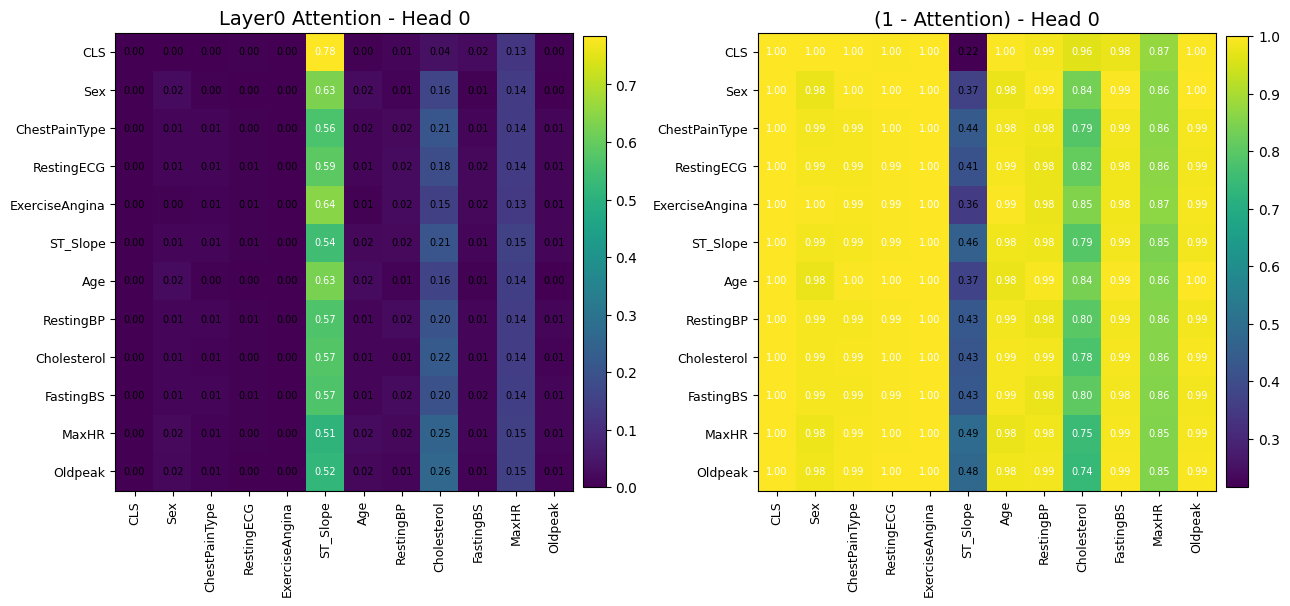

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=-0.0151 | std=0.5349
            Sex  | mean=0.0470 | std=2.2714
  ChestPainType  | mean=0.0472 | std=2.2903
     RestingECG  | mean=0.0309 | std=2.0499
 ExerciseAngina  | mean=0.0590 | std=2.3854
       ST_Slope  | mean=0.0409 | std=2.2614
            Age  | mean=-0.0264 | std=0.8822
      RestingBP  | mean=0.4204 | std=9.7697
    Cholesterol  | mean=-0.3511 | std=8.6837
      FastingBS  | mean=0.4645 | std=10.4738
          MaxHR  | mean=-0.1545 | std=3.3167
        Oldpeak  | mean=0.0396 | std=1.0933

=== Global embedding statistics ===
global mean: 0.0502
global std : 5.1619


In [36]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



## Affinity Two sample

In [37]:
import numpy as np
from collections import defaultdict
@torch.no_grad()
def collect_all_samples_from_source(model, loader, source_name):
    """
    한 source의 모든 샘플에 대해 node embedding과 affinity 추출
    
    Returns:
        all_embeddings: list of [N, D] arrays (CLS 제외한 variable nodes만)
        all_affinities: list of [N, N] arrays (1 - attention, Var-Var만)
        all_labels: list of labels
        all_feature_names: list of feature name lists
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []
    
    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        
        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None
        
        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            
            # attention shape: [B, H, T, T]
            last_att = att
            
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B, H, T, T]
        # Head 0 사용
        last_att = last_att[:, 0, :, :]  # [B, T, T]
        
        # Feature names
        var_names = extract_feature_names(batch)
        
        for b in range(B):
            # CLS 제외 (1:부터)
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N, D]
            
            # Var-Var attention만 (CLS 제외)
            var_att = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N, N]
            
            # 1 - attention = distance/affinity
            affinity = 1.0 - var_att
            
            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(batch['y'][b].item())
            all_feature_names.append(var_names)
    
    return all_embeddings, all_affinities, all_labels, all_feature_names

def compute_frobenius_distances(embeddings, affinities):
    """
    모든 샘플 쌍의 Frobenius distance 계산
    
    Returns:
        emb_distances: [n_samples, n_samples] embedding Frobenius distances
        aff_distances: [n_samples, n_samples] affinity Frobenius distances
    """
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            # Embedding Frobenius distance
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff
            
            # Affinity Frobenius distance
            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff
    
    return emb_distances, aff_distances

def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    """
    Reference 샘플과 같은/다른 레이블 내에서 가장 유사/상이한 샘플 찾기
    
    Returns:
        most_similar_same_label_idx: 같은 레이블 중 가장 유사
        most_different_other_label_idx: 다른 레이블 중 가장 상이
    """
    n = len(distances)
    ref_label = labels[reference_idx]
    
    # 같은 레이블 샘플들
    same_label_mask = np.array([labels[i] == ref_label for i in range(n)])
    same_label_mask[reference_idx] = False  # 자기자신 제외
    
    # 다른 레이블 샘플들
    other_label_mask = np.array([labels[i] != ref_label for i in range(n)])
    
    # 같은 레이블 중 가장 유사 (거리 최소)
    dist_same_label = distances[reference_idx].copy()
    dist_same_label[~same_label_mask] = np.inf
    most_similar_same_label_idx = np.argmin(dist_same_label)
    
    # 다른 레이블 중 가장 상이 (거리 최대)
    dist_other_label = distances[reference_idx].copy()
    dist_other_label[~other_label_mask] = -np.inf
    most_different_other_label_idx = np.argmax(dist_other_label)
    
    return most_similar_same_label_idx, most_different_other_label_idx

In [38]:
# 1. 데이터 수집
src = sources[1]  # 첫 번째 source
loader = loaders[src]

print(f"Collecting samples from source: {src}")
embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(model, loader, src)

print(f"Total samples collected: {len(embeddings)}")
print(f"Node embedding shape: {embeddings[0].shape}")
print(f"Affinity shape: {affinities[0].shape}")

# 2. Frobenius distance 계산
print("Computing Frobenius distances...")
emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

print(f"Embedding distance matrix shape: {emb_distances.shape}")
print(f"Affinity distance matrix shape: {aff_distances.shape}")

# 3. Reference 샘플 선택 (예: 첫 번째 샘플)
reference_idx = 1

# Affinity 기준으로 같은 레이블에서 가장 유사, 다른 레이블에서 가장 상이한 샘플 찾기
similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, aff_distances, labels)

print(f"\n=== Analysis based on Affinity Frobenius Distance (Label-aware) ===")
print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)

=== Analysis based on Affinity Frobenius Distance (Label-aware) ===
Reference sample: 1 (label: 0)

Most similar (SAME label): 607 (label: 0)
  → Affinity Frobenius distance: 0.0713

Most different (OTHER label): 62 (label: 1)
  → Affinity Frobenius distance: 0.7755



=== Reference Sample Affinity ===


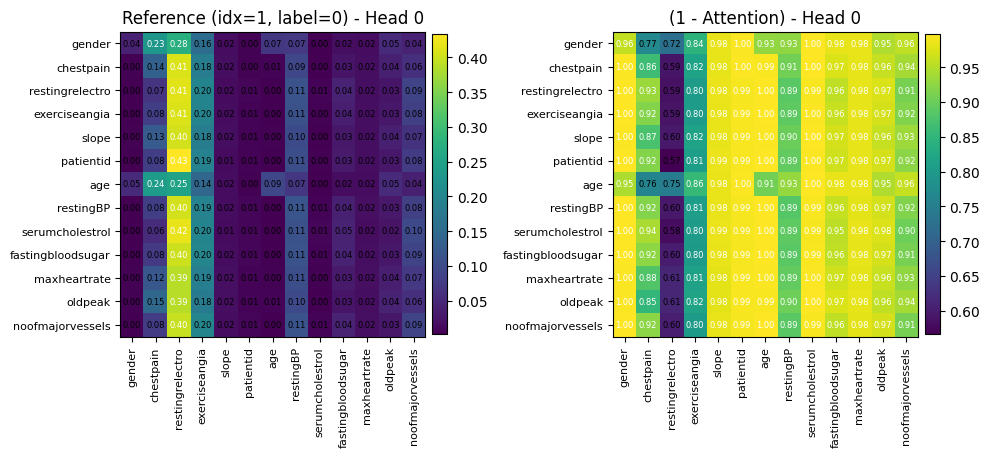


=== Most Similar Sample (SAME Label) Affinity ===
Frobenius distance: 0.0713


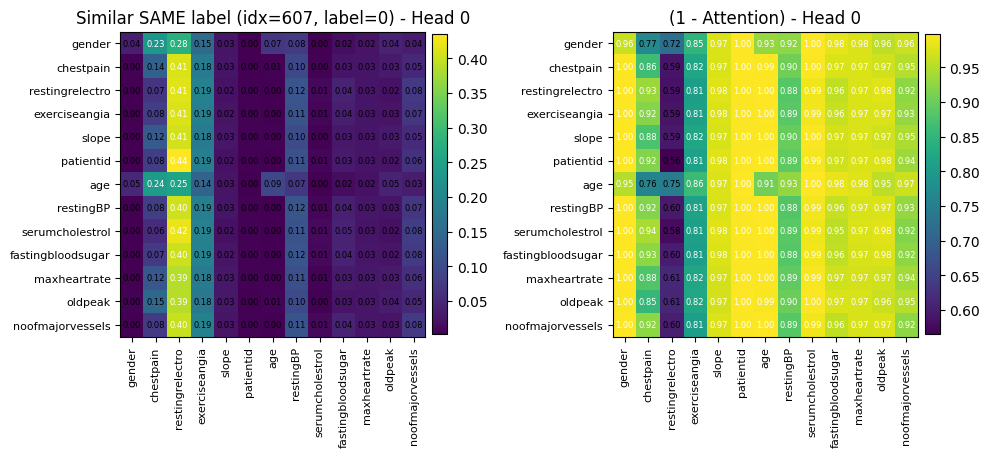


=== Most Different Sample (OTHER Label) Affinity ===
Frobenius distance: 0.7755


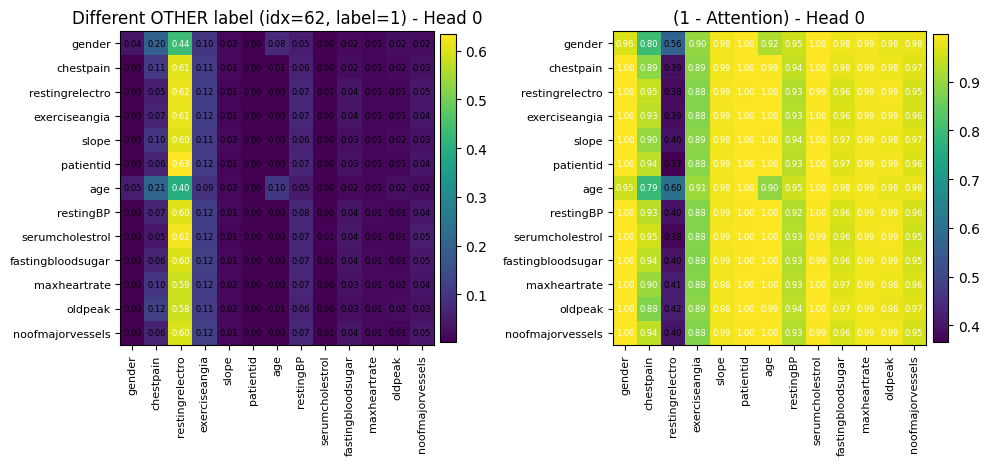

In [39]:
# 4. 시각화
feature_names = ["CLS"] + feature_names_list[0]
var_names = feature_names_list[0]

# Reference 샘플 affinity
ref_aff = affinities[reference_idx]
# Most similar (same label) 샘플 affinity
sim_aff = affinities[similar_idx]
# Most different (other label) 샘플 affinity
diff_aff = affinities[different_idx]

# 3D attention shape로 변환 (plot 함수 호환)
ref_aff_3d = ref_aff[np.newaxis, :, :]  # [1, N, N]
sim_aff_3d = sim_aff[np.newaxis, :, :]
diff_aff_3d = diff_aff[np.newaxis, :, :]

print("\n=== Reference Sample Affinity ===")
plot_attention_with_inverse(
    att=1.0 - ref_aff_3d,  # affinity를 다시 attention으로
    feature_names=var_names,
    title=f"Reference (idx={reference_idx}, label={labels[reference_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Similar Sample (SAME Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - sim_aff_3d,
    feature_names=var_names,
    title=f"Similar SAME label (idx={similar_idx}, label={labels[similar_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Different Sample (OTHER Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - diff_aff_3d,
    feature_names=var_names,
    title=f"Different OTHER label (idx={different_idx}, label={labels[different_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

## Multi-Source Joint checkpoint

In [40]:
joint_ckpt_pretrain = torch.load(joint_ckpt_pretrain_path, map_location=device)
joint_args = joint_ckpt_pretrain['args']

# Joint 모델 초기화
joint_model_pretrain = Model(
    joint_args,
    joint_args.input_dim,
    joint_args.hidden_dim,
    joint_args.output_dim,
    joint_args.dropout_rate,
    joint_args.llm_model,
    experiment_id="joint_viz",
    mode="Full"
).to(device)

joint_sd = joint_ckpt_pretrain['model_state_dict']
missing, unexpected = joint_model_pretrain.load_state_dict(joint_sd, strict=False)
print("Joint Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

joint_model_pretrain.eval()

Joint Model Loaded
Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.2, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.2, inplace=False)
      (q_proj_list): ModuleLis

## 1. Qualitative Analysis - Label-conditioned Optimal Transport Plan 

In [41]:
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities):
    """
    3개 샘플 (ref, similar, different) x 8개 LCG = 24개 Transport Plan 계산
    
    Args:
        model: Joint trained model
        sample_indices: [ref_idx, similar_idx, different_idx]
        embeddings: list of node embeddings
        affinities: list of affinity matrices
    
    Returns:
        plans: [3, 8, N, K] Transport Plans
        distances: [3, 8] FGW distances
        coordinates: [3, 8] Soft assignments (pi)
    """
    # LCG 가져오기
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    n_samples = len(sample_indices)
    
    # 결과 저장
    all_plans = []
    all_distances = []
    all_coordinates = []
    
    for idx in sample_indices:
        # Source 준비
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)  # [1, N, D]
        src_str = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)   # [1, N, N]
        
        N = src_feat.shape[1]
        
        # Expand for M LCGs
        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)  # [M, N, D]
        src_str_exp = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)    # [M, N, N]
        
        # LCG 준비
        lcg_feat_exp = lcg_feat  # [M, K, D]
        lcg_str_exp = lcg_struct  # [M, K, K]
        
        # FGW 계산 (GraphQuantizer의 compute_fgw 재현)
        dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
        
        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K
        
        alpha = model.graph_quantizer.alpha
        reg = model.graph_quantizer.reg
        
        # Solve FGW
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.detach().cpu().numpy()  # [M]
        plans = result.plan.detach().cpu().numpy()       # [M, N, K]
        
        # Soft assignment (pi)
        soft_tau = model.graph_quantizer.soft_tau
        pi = torch.softmax(-result.value / soft_tau, dim=0).detach().cpu().numpy()  # [M]
        
        all_plans.append(plans)
        all_distances.append(distances)
        all_coordinates.append(pi)
    
    all_plans = np.array(all_plans)           # [3, M, N, K]
    all_distances = np.array(all_distances)   # [3, M]
    all_coordinates = np.array(all_coordinates)  # [3, M]
    
    return all_plans, all_distances, all_coordinates

def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    """
    3 x 8 Grid로 Transport Plan 시각화
    + 각 LCG별로 Reference vs Similar, Reference vs Different의 Frobenius norm 표시
    
    Args:
        plans: [3, 8, N, K]
        coordinates: [3, 8] (pi values)
        distances: [3, 8] (FGW distances)
        sample_indices: [ref_idx, similar_idx, different_idx]
        labels: list of all labels
        var_names: list of variable names
    """
    n_samples = 3
    n_lcgs = 8
    
    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    
    # 각 LCG별 Frobenius norm 계산
    frob_norms_similar = []  # Reference vs Similar
    frob_norms_different = []  # Reference vs Different
    
    for j in range(n_lcgs):
        plan_ref = plans[0, j]      # Reference
        plan_sim = plans[1, j]      # Similar
        plan_diff = plans[2, j]     # Different
        
        frob_ref_sim = np.linalg.norm(plan_ref - plan_sim, ord='fro')
        frob_ref_diff = np.linalg.norm(plan_ref - plan_diff, ord='fro')
        
        frob_norms_similar.append(frob_ref_sim)
        frob_norms_different.append(frob_ref_diff)
    
    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            
            plan = plans[i, j]  # [N, K]
            pi = coordinates[i, j]
            dist = distances[i, j]
            
            # Heatmap
            im = ax.imshow(plan, cmap='viridis', aspect='auto')
            
            # Title
            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)
            
            # Y-axis (Source variables)
            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[sample_indices[i]]})', 
                             fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])
            
            # X-axis (LCG nodes)
            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])
            
            # Frobenius norm 표시 (Different row의 맨 아래)
            if i == n_samples - 1:
                frob_sim = frob_norms_similar[j]
                frob_diff = frob_norms_different[j]
                
                # X-axis label 아래에 Frobenius norm 추가
                ax.text(0.5, -0.5, f'Frob: Sim={frob_sim:.3f} vs Diff={frob_diff:.3f}',
                       transform=ax.transAxes,
                       ha='center', va='top',
                       fontsize=10, color='red',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            
            # Colorbar
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)  # Frobenius norm 텍스트 공간 확보
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)', 
                 fontsize=14, y=0.99)
    plt.show()

In [42]:
# 실행
print("Computing Transport Plans for 3 samples x 8 LCGs...")
sample_indices = [reference_idx, similar_idx, different_idx]

plans, distances, coordinates = compute_transport_plans_for_samples(
    joint_model_pretrain, sample_indices, embeddings, affinities
)

print(f"Plans shape: {plans.shape}")  # [3, 8, N, K]
print(f"Distances shape: {distances.shape}")  # [3, 8]
print(f"Coordinates shape: {coordinates.shape}")  # [3, 8]

print("\n=== Coordinates (pi) ===")
print("Reference:", coordinates[0])
print("Similar:", coordinates[1])
print("Different:", coordinates[2])

print("\n=== FGW Distances ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

Computing Transport Plans for 3 samples x 8 LCGs...
Plans shape: (3, 8, 13, 8)
Distances shape: (3, 8)
Coordinates shape: (3, 8)

=== Coordinates (pi) ===
Reference: [0.15300073 0.08871901 0.1408908  0.12874945 0.10350119 0.14201276
 0.11125309 0.131873  ]
Similar: [0.15321048 0.08860824 0.14100173 0.12856965 0.1035917  0.1420479
 0.11115881 0.13181144]
Different: [0.15359244 0.08839368 0.14167233 0.12795544 0.10236211 0.14085409
 0.1110807  0.13408919]

=== FGW Distances ===
Reference: [0.37532824 0.4298251  0.383574   0.3925857  0.4144142  0.38278085
 0.40719175 0.3901886 ]
Similar: [0.37537974 0.43013856 0.3836838  0.39291394 0.4145153  0.38294458
 0.40746504 0.39042377]
Different: [0.37482294 0.43007314 0.38290152 0.393085   0.41540158 0.38348076
 0.40722752 0.3884027 ]


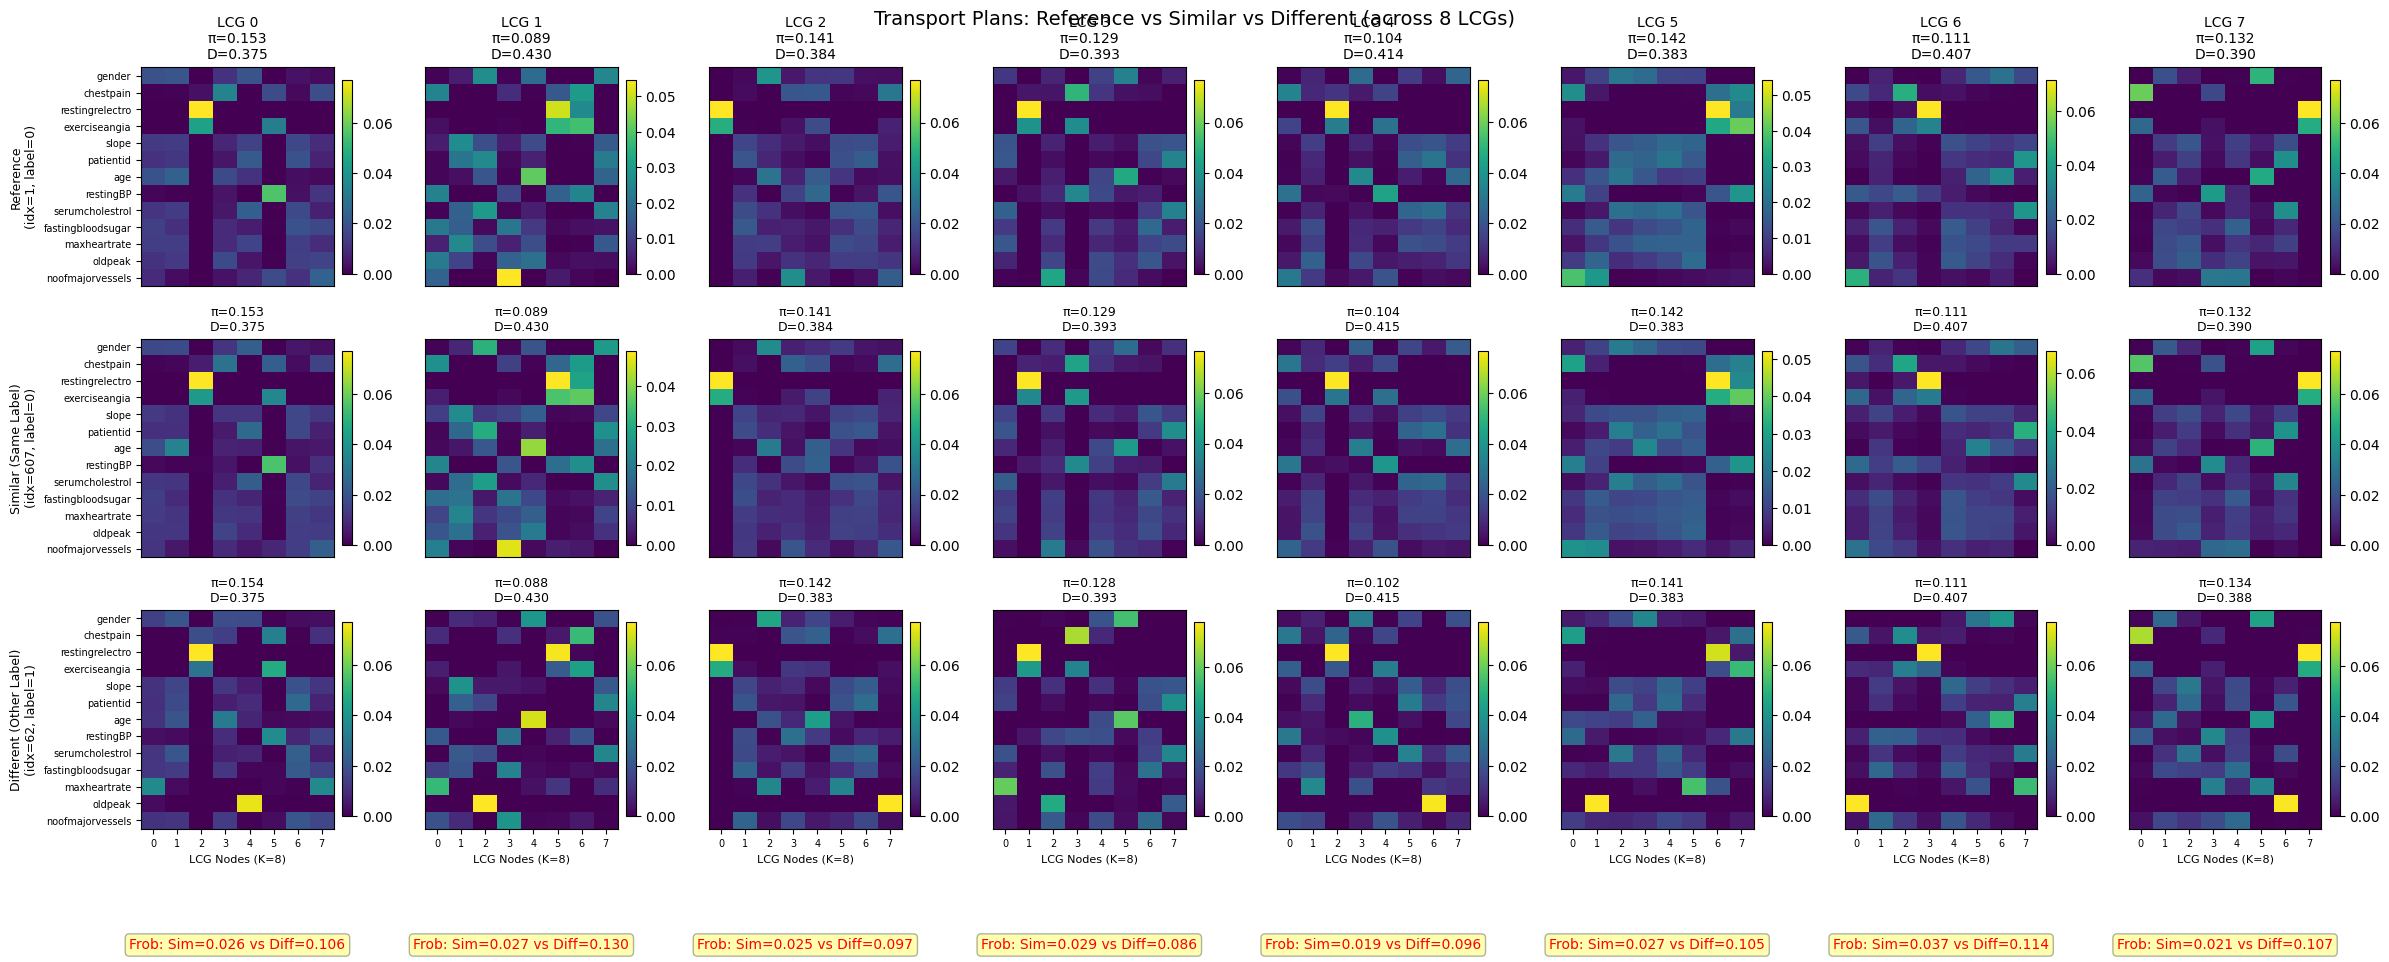

In [43]:
# 시각화
plot_transport_plans_grid(
    plans, coordinates, distances, 
    sample_indices, labels, var_names
)

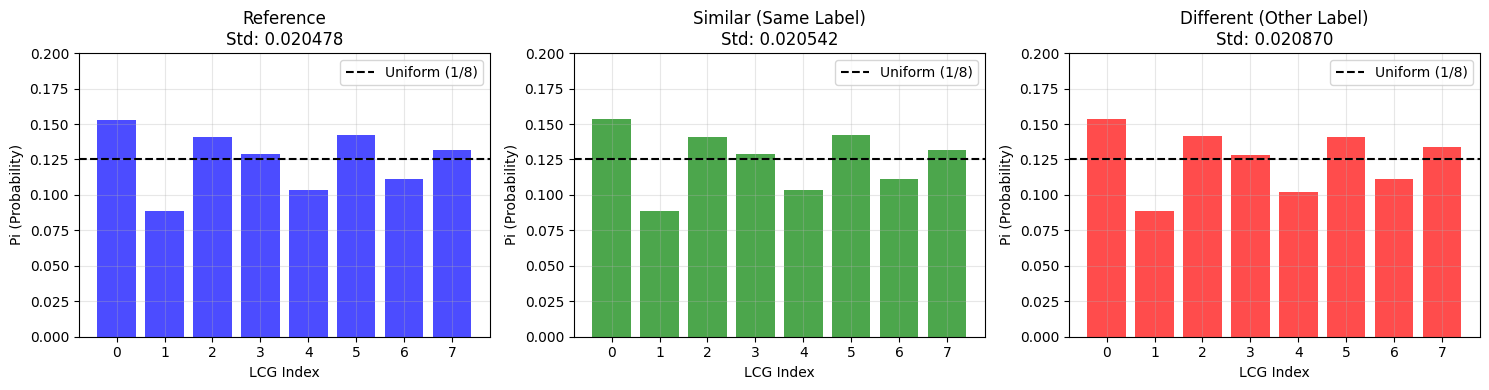

In [44]:
# 시각화: Pi 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(8), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Qualitative Analysis - Optimal Transport Plan + Coordinate (1)

- Source 별 결과

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 0 (label: 1)

Most similar (SAME label): 44 (label: 1)
  → distance: 0.0368

Most different (OTHER label): 977 (label: 0)
  → distance: 0.7843

Computing Transport Plans for 3 samples x 8 LCGs...


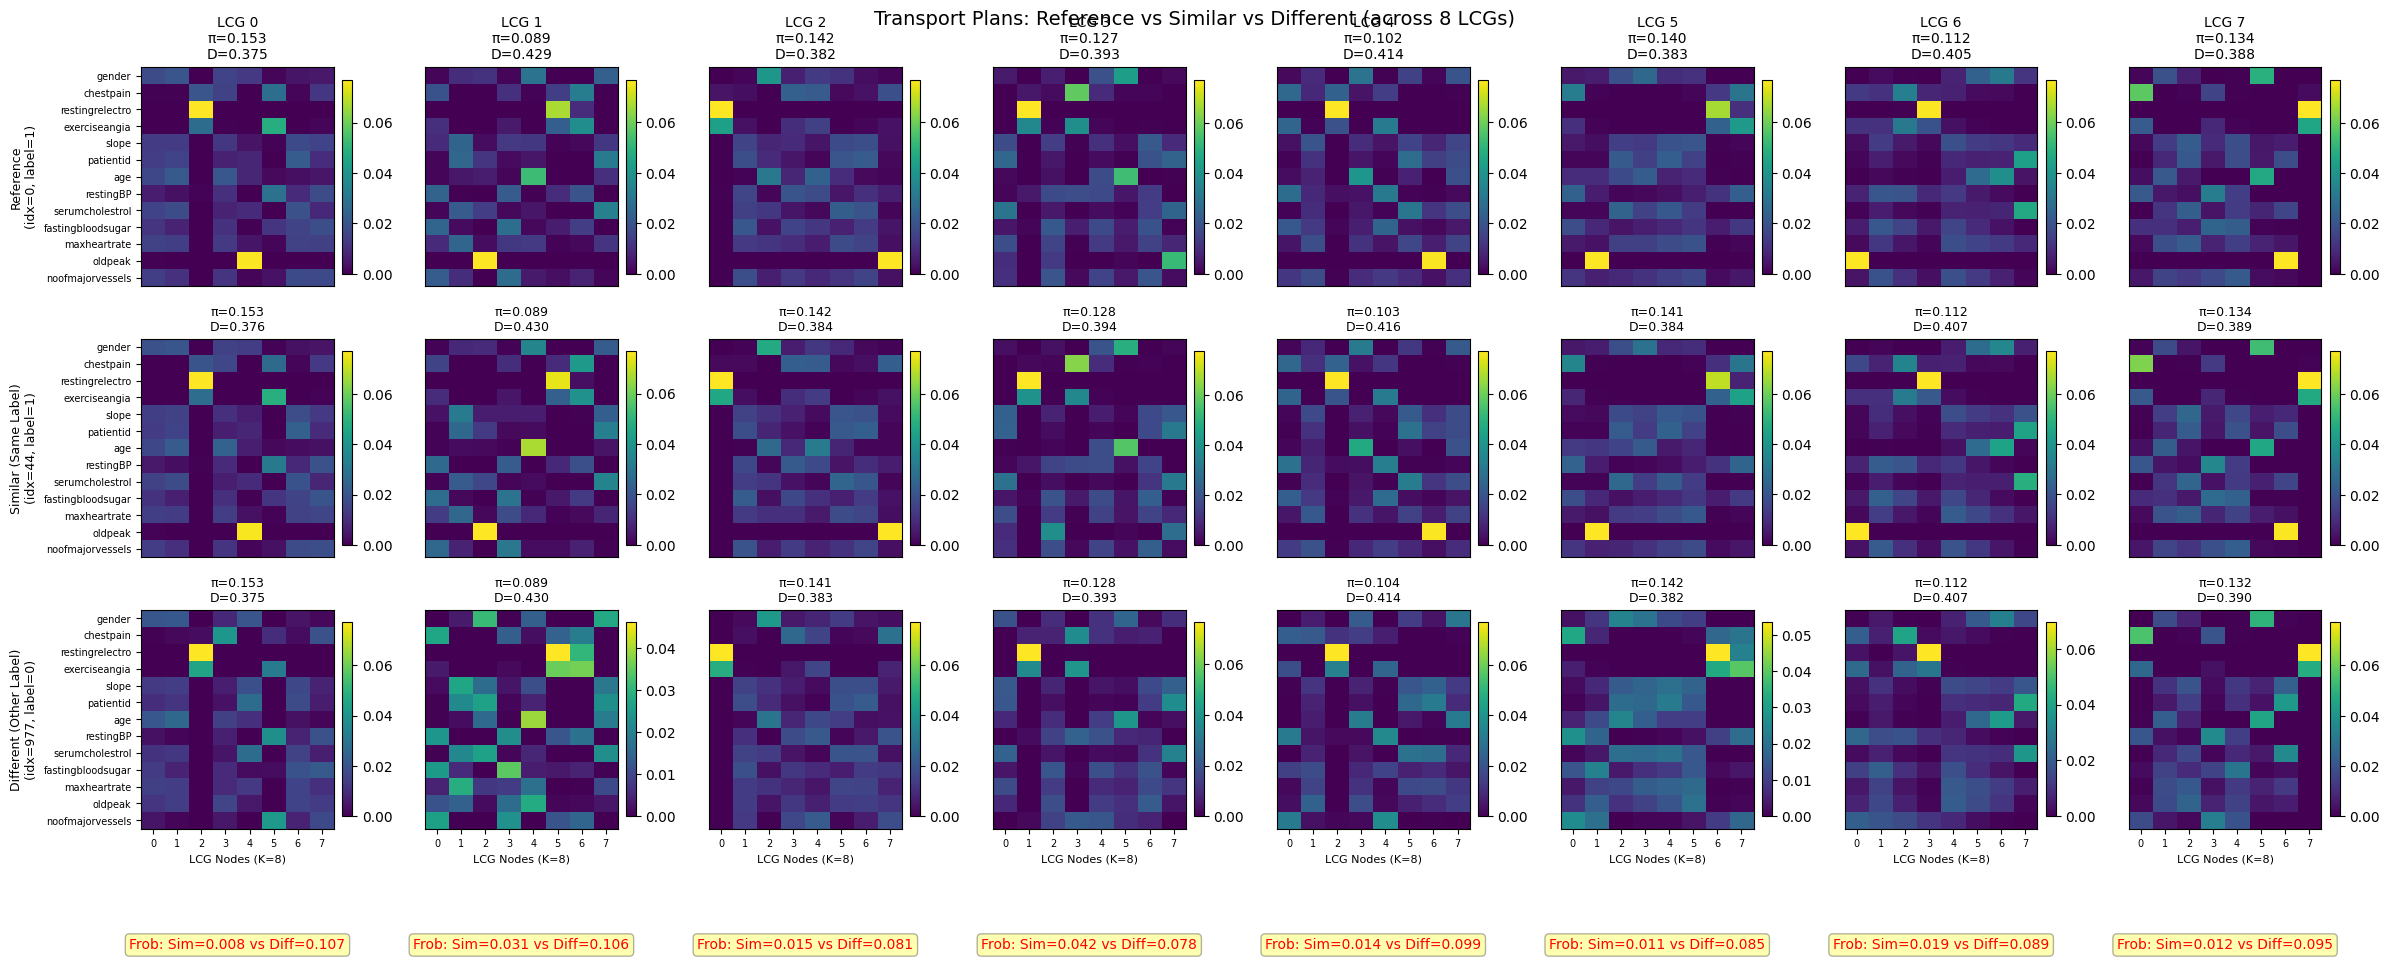

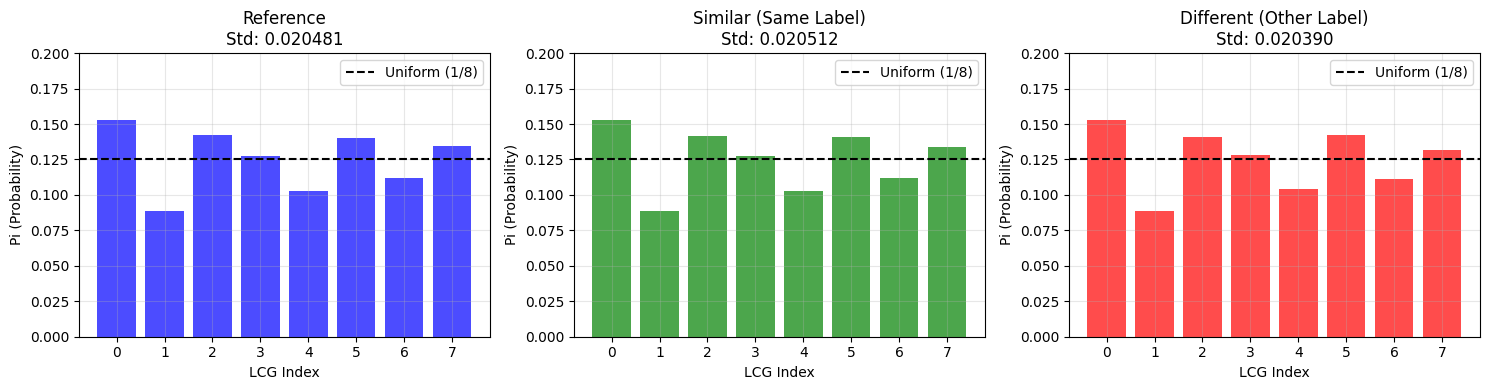

In [45]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# =========================================================
# 0) (helper) label-aware ref/sim/diff pick
# =========================================================
def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    n = len(distances)
    ref_label = labels[reference_idx]

    same_label_mask = np.array([labels[i] == ref_label for i in range(n)], dtype=bool)
    same_label_mask[reference_idx] = False

    other_label_mask = np.array([labels[i] != ref_label for i in range(n)], dtype=bool)

    dist_same = distances[reference_idx].copy()
    dist_same[~same_label_mask] = np.inf
    most_similar_same_label_idx = int(np.argmin(dist_same))

    dist_other = distances[reference_idx].copy()
    dist_other[~other_label_mask] = -np.inf
    most_different_other_label_idx = int(np.argmax(dist_other))

    return most_similar_same_label_idx, most_different_other_label_idx


# =========================================================
# 1) collect all samples (embeddings + affinity) from ONE source loader
#    - 너가 준 로직 그대로: last_att(head0) -> var-var -> affinity = 1-att
# =========================================================
@torch.no_grad()
def collect_all_samples_from_source(model, loader, device, extract_feature_names_fn=None):
    """
    Returns:
        all_embeddings: list of [N,D] (CLS 제외 var nodes)
        all_affinities: list of [N,N] (1-attention, Var-Var)
        all_labels: list[int]
        all_feature_names: list[var_names]  (extract_feature_names_fn 제공 시)
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []

    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        # desc/name/value gather (너 코드 그대로)
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])

        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name  = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)

        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None

        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B,H,T,T] -> head0 -> [B,T,T]
        last_att = last_att[:, 0, :, :]

        # var names
        if extract_feature_names_fn is not None:
            var_names = extract_feature_names_fn(batch)
        else:
            var_names = None

        for b in range(B):
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()          # [N,D]
            var_att  = last_att[b, 1:, 1:].detach().cpu().numpy()        # [N,N]
            affinity = 1.0 - var_att                                    # [N,N]

            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(int(batch['y'][b].item()))
            all_feature_names.append(var_names)

    return all_embeddings, all_affinities, all_labels, all_feature_names


# =========================================================
# 2) Frobenius distance matrix (O(n^2))
# =========================================================
def compute_frobenius_distances(embeddings, affinities):
    n = len(embeddings)
    emb_distances = np.zeros((n, n), dtype=np.float32)
    aff_distances = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in range(i + 1, n):
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff

            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff

    return emb_distances, aff_distances


# =========================================================
# 3) FGW plans + pi (너 코드 그대로)
#    NOTE: solve_gromov_batch는 네 세션에 이미 import 되어 있어야 함
# =========================================================
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities, device):
    lcg_feat, lcg_struct = model.latent_graph()  # [M,K,D], [M,K,K]
    M, K, D = lcg_feat.shape

    all_plans = []
    all_distances = []
    all_coordinates = []

    for idx in sample_indices:
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)   # [1,N,D]
        src_str  = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)  # [1,N,N]
        N = src_feat.shape[1]

        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)
        src_str_exp  = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)

        dist_sq = torch.cdist(src_feat_exp, lcg_feat, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))

        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K

        alpha = model.graph_quantizer.alpha
        reg   = model.graph_quantizer.reg

        result = solve_gromov_batch(
            src_str_exp, lcg_struct, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )

        distances = result.value.detach().cpu().numpy()  # [M]
        plans     = result.plan.detach().cpu().numpy()   # [M,N,K]

        soft_tau = model.graph_quantizer.soft_tau
        pi = torch.softmax(-result.value / soft_tau, dim=0).detach().cpu().numpy()  # [M]

        all_plans.append(plans)
        all_distances.append(distances)
        all_coordinates.append(pi)

    return np.array(all_plans), np.array(all_distances), np.array(all_coordinates)


# =========================================================
# 4) plot grid (너 코드 그대로)
# =========================================================
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    n_samples = 3
    n_lcgs = 8

    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']

    frob_norms_similar = []
    frob_norms_different = []
    for j in range(n_lcgs):
        plan_ref  = plans[0, j]
        plan_sim  = plans[1, j]
        plan_diff = plans[2, j]
        frob_norms_similar.append(np.linalg.norm(plan_ref - plan_sim, ord='fro'))
        frob_norms_different.append(np.linalg.norm(plan_ref - plan_diff, ord='fro'))

    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            plan = plans[i, j]
            pi   = coordinates[i, j]
            dist = distances[i, j]

            im = ax.imshow(plan, cmap='viridis', aspect='auto')

            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)

            if j == 0:
                ax.set_ylabel(
                    f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[sample_indices[i]]})',
                    fontsize=9
                )
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])

            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])

            if i == n_samples - 1:
                ax.text(
                    0.5, -0.5, f'Frob: Sim={frob_norms_similar[j]:.3f} vs Diff={frob_norms_different[j]:.3f}',
                    transform=ax.transAxes,
                    ha='center', va='top',
                    fontsize=10, color='red',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
                )

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)',
                 fontsize=14, y=0.99)
    plt.show()


# =========================================================
# 5) plot pi 비교 (너 코드 그대로)
# =========================================================
def plot_pi_bars(coordinates):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    colors = ['blue', 'green', 'red']

    for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
        ax = axes[i]
        ax.bar(range(8), coord, color=color, alpha=0.7)
        ax.set_xlabel('LCG Index')
        ax.set_ylabel('Pi (Probability)')
        ax.set_title(f'{name}\nStd: {coord.std():.6f}')
        ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
        ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# =========================================================
# 6) WRAP-UP (한 방에)
#    - model, loader만 넣으면: 수집 -> 거리 -> ref/sim/diff -> FGW -> 두 plot
#    - var_names는 extract_feature_names로 뽑거나, 없으면 feature_names_list[0]에서 가져옴
# =========================================================
def run_transport_plan_wrapup(
    model,
    loader,
    device,
    source_name="",
    reference_idx=0,
    distance_mode="affinity",   # "affinity" or "embedding"
    extract_feature_names_fn=None,
):
    print(f"Collecting samples from source: {source_name}")
    embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(
        model=model,
        loader=loader,
        device=device,
        extract_feature_names_fn=extract_feature_names_fn
    )

    print(f"Total samples collected: {len(embeddings)}")
    print(f"Node embedding shape: {embeddings[0].shape}")
    print(f"Affinity shape: {affinities[0].shape}")

    print("Computing Frobenius distances...")
    emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

    print(f"Embedding distance matrix shape: {emb_distances.shape}")
    print(f"Affinity distance matrix shape: {aff_distances.shape}")

    if reference_idx < 0 or reference_idx >= len(labels):
        raise IndexError(f"reference_idx out of range: {reference_idx} (n={len(labels)})")

    dist_mat = aff_distances if distance_mode == "affinity" else emb_distances
    similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, dist_mat, labels)

    print(f"\n=== Analysis based on {distance_mode} Frobenius Distance (Label-aware) ===")
    print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
    print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
    print(f"  → distance: {dist_mat[reference_idx, similar_idx]:.4f}")
    print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
    print(f"  → distance: {dist_mat[reference_idx, different_idx]:.4f}")

    sample_indices = [reference_idx, similar_idx, different_idx]

    print("\nComputing Transport Plans for 3 samples x 8 LCGs...")
    plans, distances, coordinates = compute_transport_plans_for_samples(
        model=model,
        sample_indices=sample_indices,
        embeddings=embeddings,
        affinities=affinities,
        device=device
    )

    # var_names: 우선 feature_names_list[0] (너 코드처럼)
    # extract_feature_names_fn이 batch->list를 리턴하면 이미 list로 들어있음
    var_names = feature_names_list[0]
    if var_names is None:
        # fallback: generic names
        N = embeddings[0].shape[0]
        var_names = [f"v{i}" for i in range(N)]

    # ---- plots (너 방식 그대로) ----
    plot_transport_plans_grid(
        plans, coordinates, distances,
        sample_indices=sample_indices,
        labels=labels,
        var_names=var_names
    )
    plot_pi_bars(coordinates)

    return {
        "embeddings": embeddings,
        "affinities": affinities,
        "labels": labels,
        "feature_names_list": feature_names_list,
        "emb_distances": emb_distances,
        "aff_distances": aff_distances,
        "sample_indices": sample_indices,
        "plans": plans,
        "distances": distances,
        "coordinates": coordinates,
        "var_names": var_names
    }


# =========================================================
# 실행 예시
# =========================================================
src = sources[1]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=0,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)


Total samples collected: 270
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (270, 270)
Affinity distance matrix shape: (270, 270)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 5 (label: 0)

Most similar (SAME label): 93 (label: 0)
  → distance: 0.0231

Most different (OTHER label): 240 (label: 1)
  → distance: 0.7205

Computing Transport Plans for 3 samples x 8 LCGs...


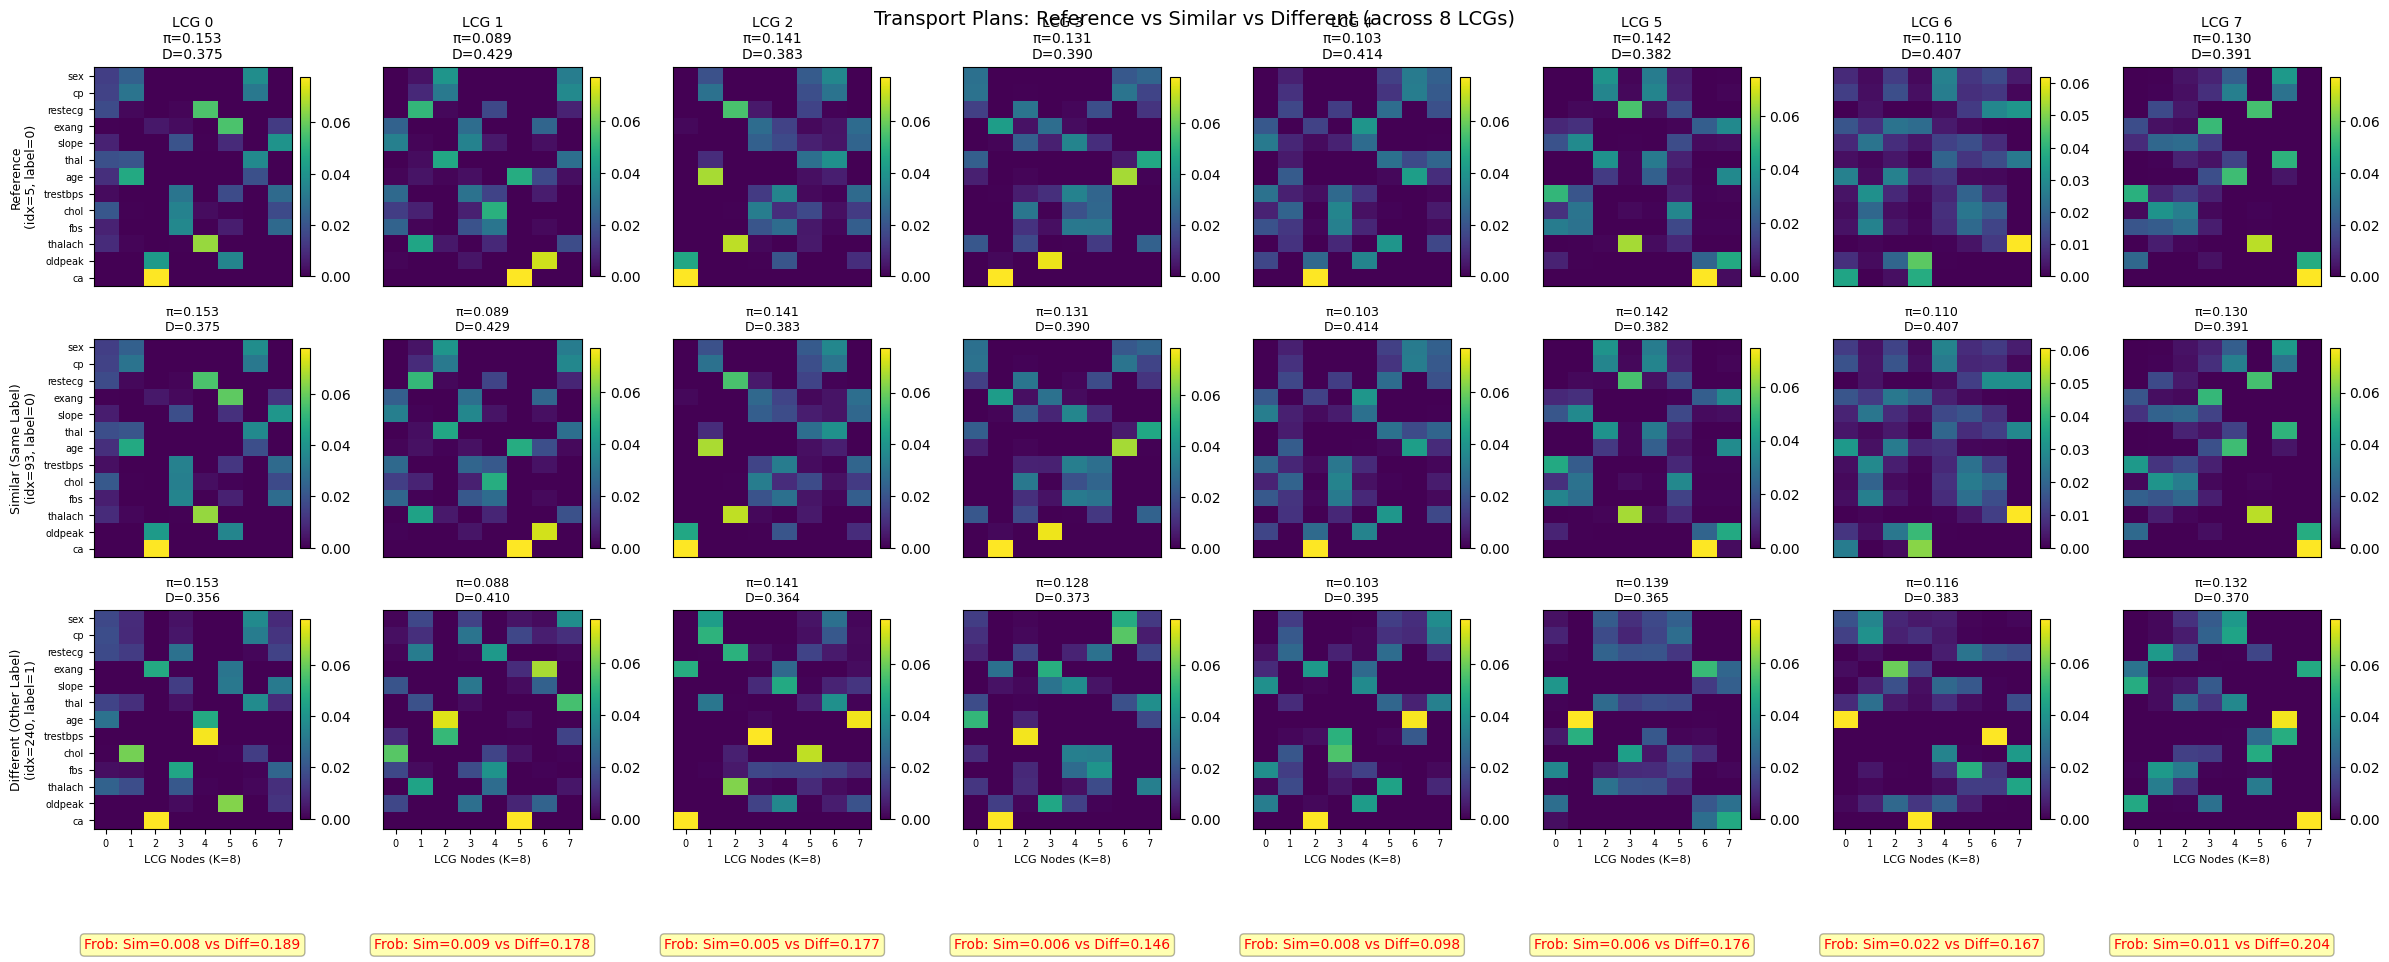

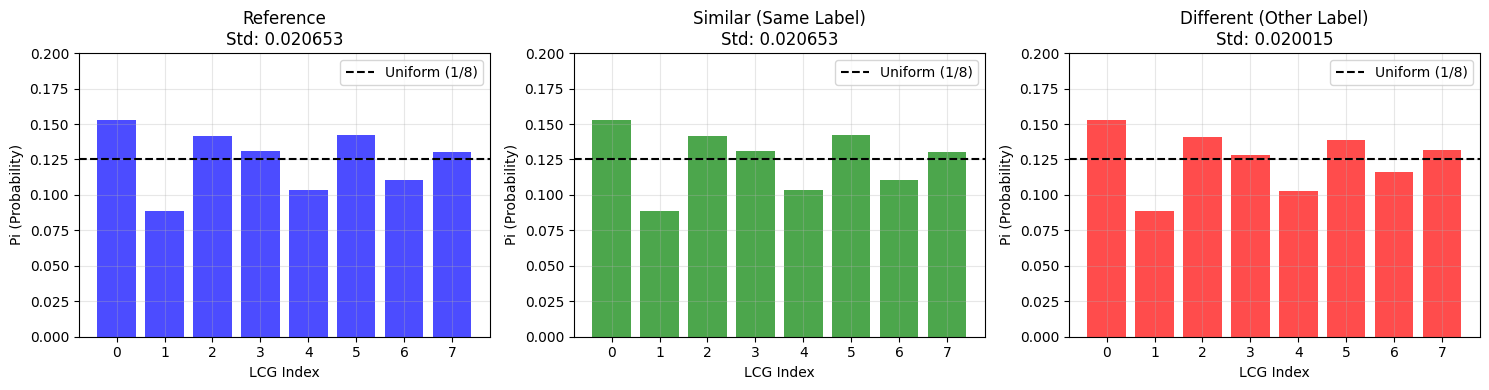

In [46]:
src = sources[2]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=5,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)

In [47]:
sources[3]

'Erbil_Cardiovascular_Health_Dataset'

Total samples collected: 287
Node embedding shape: (20, 768)
Affinity shape: (20, 20)
Computing Frobenius distances...
Embedding distance matrix shape: (287, 287)
Affinity distance matrix shape: (287, 287)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 5 (label: 0)

Most similar (SAME label): 158 (label: 0)
  → distance: 0.0855

Most different (OTHER label): 238 (label: 1)
  → distance: 0.8974

Computing Transport Plans for 3 samples x 8 LCGs...


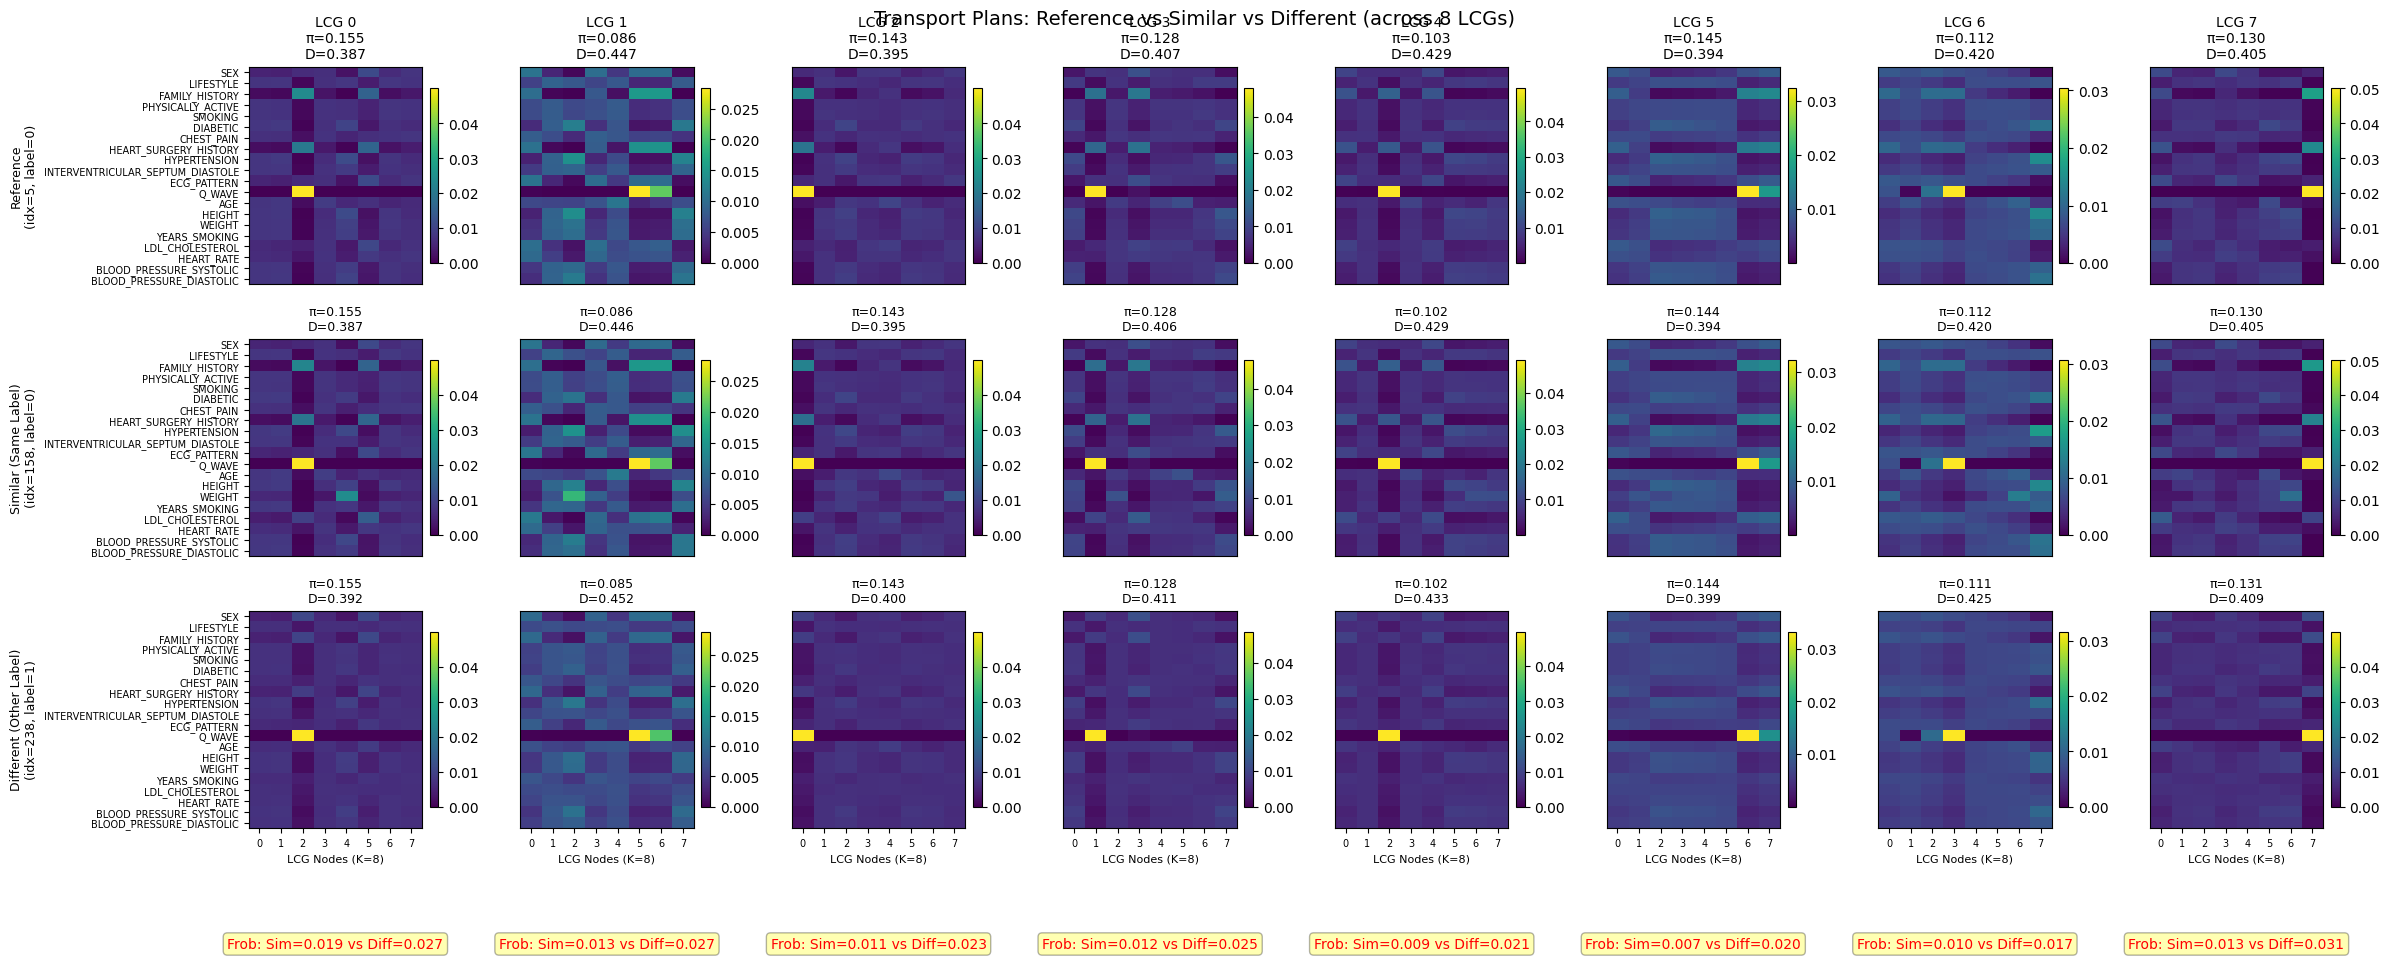

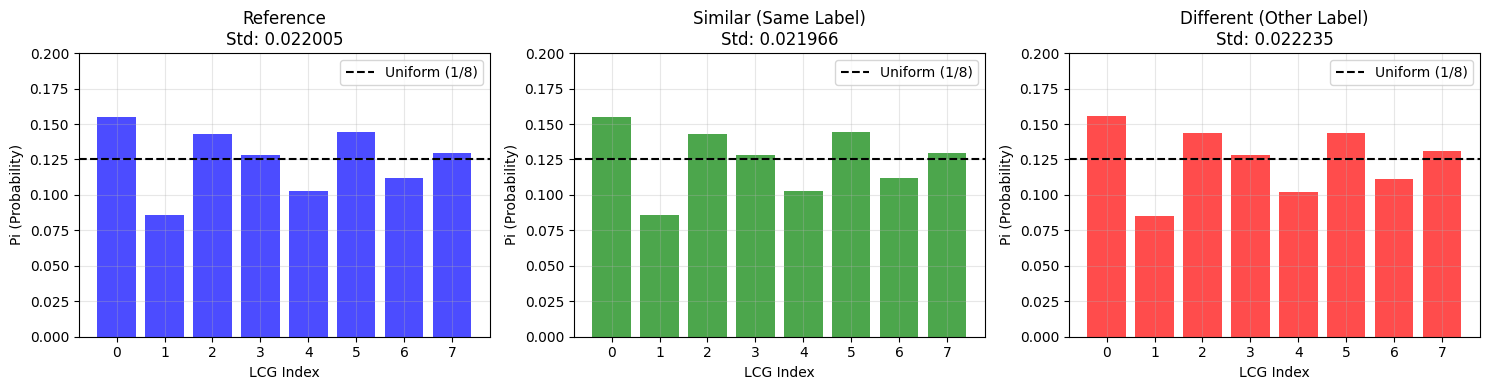

In [48]:
src = sources[3]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=5,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)

Total samples collected: 918
Node embedding shape: (11, 768)
Affinity shape: (11, 11)
Computing Frobenius distances...
Embedding distance matrix shape: (918, 918)
Affinity distance matrix shape: (918, 918)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 0 (label: 1)

Most similar (SAME label): 280 (label: 1)
  → distance: 0.0350

Most different (OTHER label): 813 (label: 0)
  → distance: 0.7195

Computing Transport Plans for 3 samples x 8 LCGs...


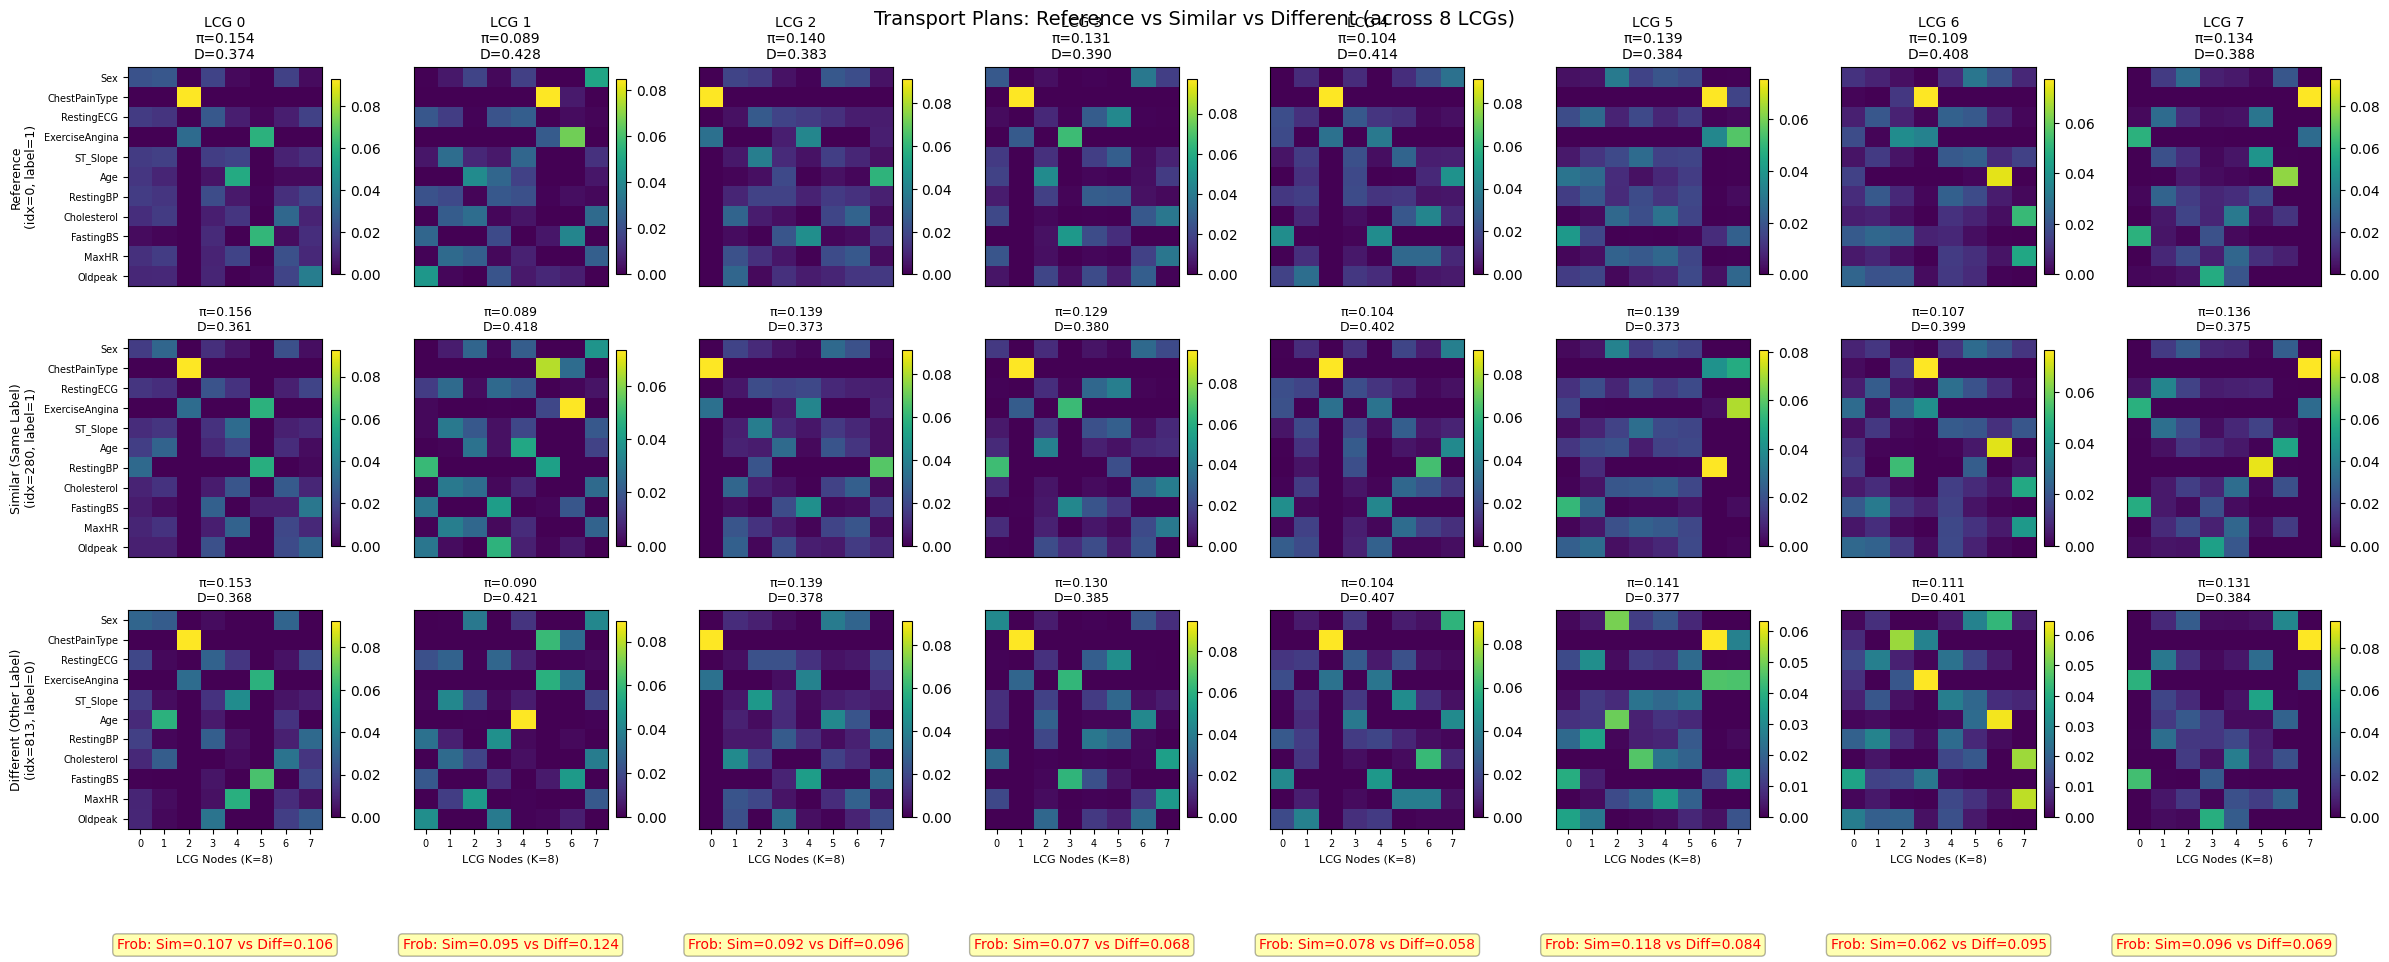

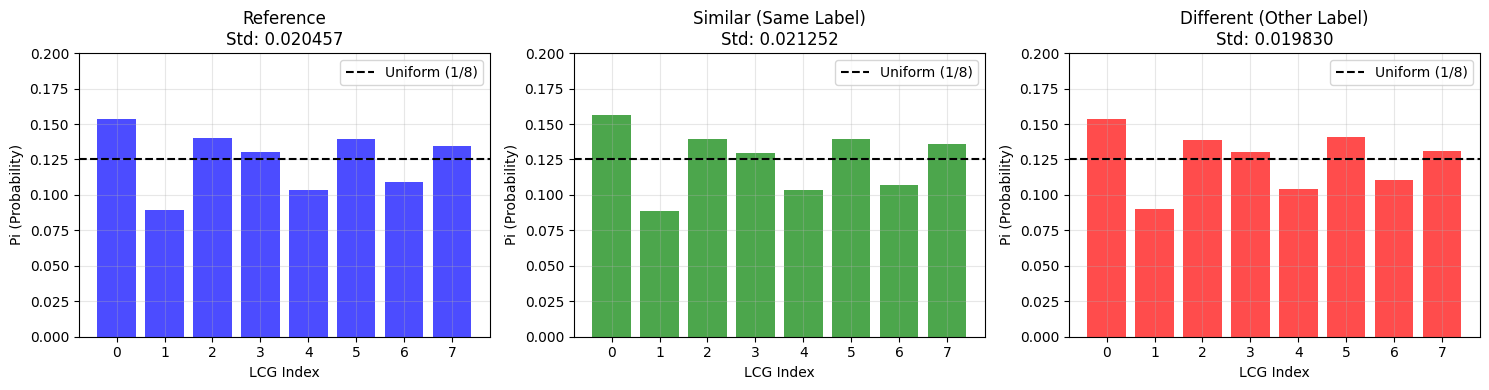

In [49]:
src = sources[0]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=0,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  
)

## Qualitative - Transport Plan, Coordinate (2)

In [50]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 네 환경에서 이미 쓰던 것 그대로
# from ot.batch import solve_gromov_batch


# =========================================================
# (A) 너가 준 그대로: loader -> embeddings / affinities / labels 수집
# =========================================================
@torch.no_grad()
def collect_all_samples_from_source(model, loader, device, extract_feature_names_fn):
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []

    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name  = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)

        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None

        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B,H,T,T] -> head 0
        last_att = last_att[:, 0, :, :]  # [B,T,T]

        # Feature names
        var_names = extract_feature_names_fn(batch)

        for b in range(B):
            # CLS 제외
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N,D]
            var_att  = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N,N]
            affinity = 1.0 - var_att  # (너 코드 그대로)

            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(int(batch['y'][b].item()))
            all_feature_names.append(var_names)

    return all_embeddings, all_affinities, all_labels, all_feature_names


# =========================================================
# (B) 너가 준 그대로: Frobenius distance
# =========================================================
def compute_frobenius_distances(embeddings, affinities):
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff

            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff

    return emb_distances, aff_distances


# =========================================================
# (C) 핵심 수정: reference 기준
#   - similar: 같은 label 중 affinity distance 최소
#   - other  : 다른 label 중 affinity distance 최소 (attention은 유사, label만 다름)
# =========================================================
def find_similar_same_and_similar_other_by_label(reference_idx, distances, labels):
    n = len(labels)
    ref_label = labels[reference_idx]

    same_mask = np.array([labels[i] == ref_label for i in range(n)], dtype=bool)
    same_mask[reference_idx] = False

    other_mask = np.array([labels[i] != ref_label for i in range(n)], dtype=bool)

    if same_mask.sum() == 0:
        raise RuntimeError(f"No same-label sample exists for reference label={ref_label}")
    if other_mask.sum() == 0:
        raise RuntimeError("No other-label sample exists")

    d_same = distances[reference_idx].copy()
    d_same[~same_mask] = np.inf
    similar_idx = int(np.argmin(d_same))

    d_other = distances[reference_idx].copy()
    d_other[~other_mask] = np.inf
    other_idx = int(np.argmin(d_other))  # <-- '다른 레이블인데 attention 유사'를 강제

    return similar_idx, other_idx


# =========================================================
# (D) 너가 준 그대로: transport plan + pi
# =========================================================
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities, device):
    lcg_feat, lcg_struct = model.latent_graph()  # [M,K,D], [M,K,K]
    M, K, D = lcg_feat.shape

    all_plans = []
    all_distances = []
    all_coordinates = []

    for idx in sample_indices:
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)   # [1,N,D]
        src_str  = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)  # [1,N,N]
        N = src_feat.shape[1]

        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)  # [M,N,D]
        src_str_exp  = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)   # [M,N,N]

        dist_sq = torch.cdist(src_feat_exp, lcg_feat, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))

        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K

        alpha = model.graph_quantizer.alpha
        reg   = model.graph_quantizer.reg

        result = solve_gromov_batch(
            src_str_exp, lcg_struct, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )

        distances = result.value.detach().cpu().numpy()  # [M]
        plans     = result.plan.detach().cpu().numpy()   # [M,N,K]

        soft_tau = model.graph_quantizer.soft_tau
        pi = torch.softmax(-result.value / soft_tau, dim=0).detach().cpu().numpy()  # [M]

        all_plans.append(plans)
        all_distances.append(distances)
        all_coordinates.append(pi)

    return np.array(all_plans), np.array(all_distances), np.array(all_coordinates)  # [3,M,N,K], [3,M], [3,M]


# =========================================================
# (E) 너가 준 그대로: 3x8 plan grid
# =========================================================
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    n_samples = 3
    n_lcgs = 8

    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']

    frob_norms_similar = []
    frob_norms_different = []
    for j in range(n_lcgs):
        plan_ref = plans[0, j]
        plan_sim = plans[1, j]
        plan_diff = plans[2, j]
        frob_norms_similar.append(np.linalg.norm(plan_ref - plan_sim, ord='fro'))
        frob_norms_different.append(np.linalg.norm(plan_ref - plan_diff, ord='fro'))

    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            plan = plans[i, j]
            pi   = coordinates[i, j]
            dist = distances[i, j]

            im = ax.imshow(plan, cmap='viridis', aspect='auto')

            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)

            if j == 0:
                ax.set_ylabel(
                    f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[sample_indices[i]]})',
                    fontsize=9
                )
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])

            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])

            if i == n_samples - 1:
                ax.text(
                    0.5, -0.5,
                    f'Frob: Sim={frob_norms_similar[j]:.3f} vs Diff={frob_norms_different[j]:.3f}',
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=10, color='red',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
                )

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)

    plt.show()


# =========================================================
# (F) 요청한 2x3: (위) coordinate bar / (아래) attention map
#   - coordinate 색: 파란/초록/빨강 (원래 코드 그대로)
#   - y-limit / uniform line / grid도 원래 코드 그대로
#   - [수정] colorbar가 attention map 위에 겹치지 않게: 오른쪽에 전용 cax를 만들어서 밖으로 뺌
# =========================================================
def plot_coord_and_attention_2x3(sample_indices, coordinates, affinities, labels, var_names, title_prefix=""):
    # coordinates: [3,M]
    M = coordinates.shape[1]

    # affinity = 1 - att 이었으니 attention 복원
    atts = [1.0 - affinities[idx] for idx in sample_indices]

    # attention 비교 가능하게 shared scale
    vmin = min(float(np.min(a)) for a in atts)
    vmax = max(float(np.max(a)) for a in atts)

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))

    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    colors = ['blue', 'green', 'red']  # <-- 원래 코드 그대로

    # ---- top row: coordinate (원래 스타일 그대로) ----
    for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
        ax = axes[0, i]
        ax.bar(range(M), coord, color=color, alpha=0.7)
        ax.set_xlabel('LCG Index')
        ax.set_ylabel('Pi (Probability)')
        ax.set_title(f'{name}\nStd: {coord.std():.6f}')
        ax.set_ylim([0, max(0.2, float(coord.max()) * 1.1)])
        ax.axhline(y=1/M, color='black', linestyle='--', label=f'Uniform (1/{M})')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # ---- bottom row: attention map ----
    ims = []
    for i in range(3):
        ax = axes[1, i]
        im = ax.imshow(atts[i], cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        ims.append(im)
        ax.set_title('Attention (Var-Var)')
        ax.set_xlabel('variables')
        ax.set_ylabel('variables')

        ax.set_xticks(range(len(var_names)))
        ax.set_yticks(range(len(var_names)))
        ax.set_xticklabels(var_names, rotation=90, fontsize=7)
        ax.set_yticklabels(var_names, fontsize=7)

    fig.suptitle(f'{title_prefix} 2x3: Coordinate(pi) + Attention map', fontsize=14)

    # [핵심] 오른쪽 공간을 먼저 확보하고, colorbar 전용 축(cax)을 만들어 바깥으로 뺌
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])  # <-- 오른쪽 8% 비워두기

    # bottom-right attention axis 기준으로 cax 위치 계산(겹침 방지)
    pos = axes[1, 2].get_position()
    cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.012, pos.height])  # (x, y, w, h)
    fig.colorbar(ims[-1], cax=cax)

    plt.show()


# =========================================================
# (G) WRAP-UP: 한 방에 실행
#   reference 기준:
#     - similar: same label & attention 유사(aff dist 최소)
#     - other  : other label & attention 유사(aff dist 최소)
# =========================================================
def run_ref_sim_other_attention_viz(
    model,
    loader,
    device,
    source_name,
    extract_feature_names_fn,
    reference_idx=0
):
    print(f"Collecting samples from source: {source_name}")
    embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(
        model=model,
        loader=loader,
        device=device,
        extract_feature_names_fn=extract_feature_names_fn
    )

    print(f"Total samples collected: {len(embeddings)}")
    print(f"Node embedding shape: {embeddings[0].shape}")
    print(f"Affinity shape: {affinities[0].shape}")

    print("Computing Frobenius distances...")
    emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

    similar_idx, other_idx = find_similar_same_and_similar_other_by_label(
        reference_idx=reference_idx,
        distances=aff_distances,
        labels=labels
    )

    print("\n=== Picked indices ===")
    print(f"Reference: {reference_idx} (label={labels[reference_idx]})")
    print(f"Similar (SAME label, min aff-dist): {similar_idx} (label={labels[similar_idx]}), dist={aff_distances[reference_idx, similar_idx]:.4f}")
    print(f"Other  (OTHER label, min aff-dist): {other_idx} (label={labels[other_idx]}), dist={aff_distances[reference_idx, other_idx]:.4f}")

    sample_indices = [int(reference_idx), int(similar_idx), int(other_idx)]

    # var names
    var_names = feature_names_list[0]
    if var_names is None:
        N = embeddings[0].shape[0]
        var_names = [f"v{i}" for i in range(N)]

    # FGW + 시각화
    plans, distances, coordinates = compute_transport_plans_for_samples(
        model=model,
        sample_indices=sample_indices,
        embeddings=embeddings,
        affinities=affinities,
        device=device
    )

    # 3x8 (원래 코드)
    plot_transport_plans_grid(
        plans=plans,
        coordinates=coordinates,
        distances=distances,
        sample_indices=sample_indices,
        labels=labels,
        var_names=var_names
    )

    # 2x3 (요청한 것 + coordinate 색/스타일 원래대로)  <-- 여기 colorbar 겹침 수정됨
    plot_coord_and_attention_2x3(
        sample_indices=sample_indices,
        coordinates=coordinates,
        affinities=affinities,
        labels=labels,
        var_names=var_names,
        title_prefix=f"[{source_name}]"
    )

    return {
        "embeddings": embeddings,
        "affinities": affinities,
        "labels": labels,
        "feature_names_list": feature_names_list,
        "aff_distances": aff_distances,
        "sample_indices": sample_indices,
        "plans": plans,
        "distances": distances,
        "coordinates": coordinates,
        "var_names": var_names
    }




Total samples collected: 918
Node embedding shape: (11, 768)
Affinity shape: (11, 11)
Computing Frobenius distances...

=== Picked indices ===
Reference: 16 (label=1)
Similar (SAME label, min aff-dist): 368 (label=1), dist=0.0102
Other  (OTHER label, min aff-dist): 275 (label=0), dist=0.0195


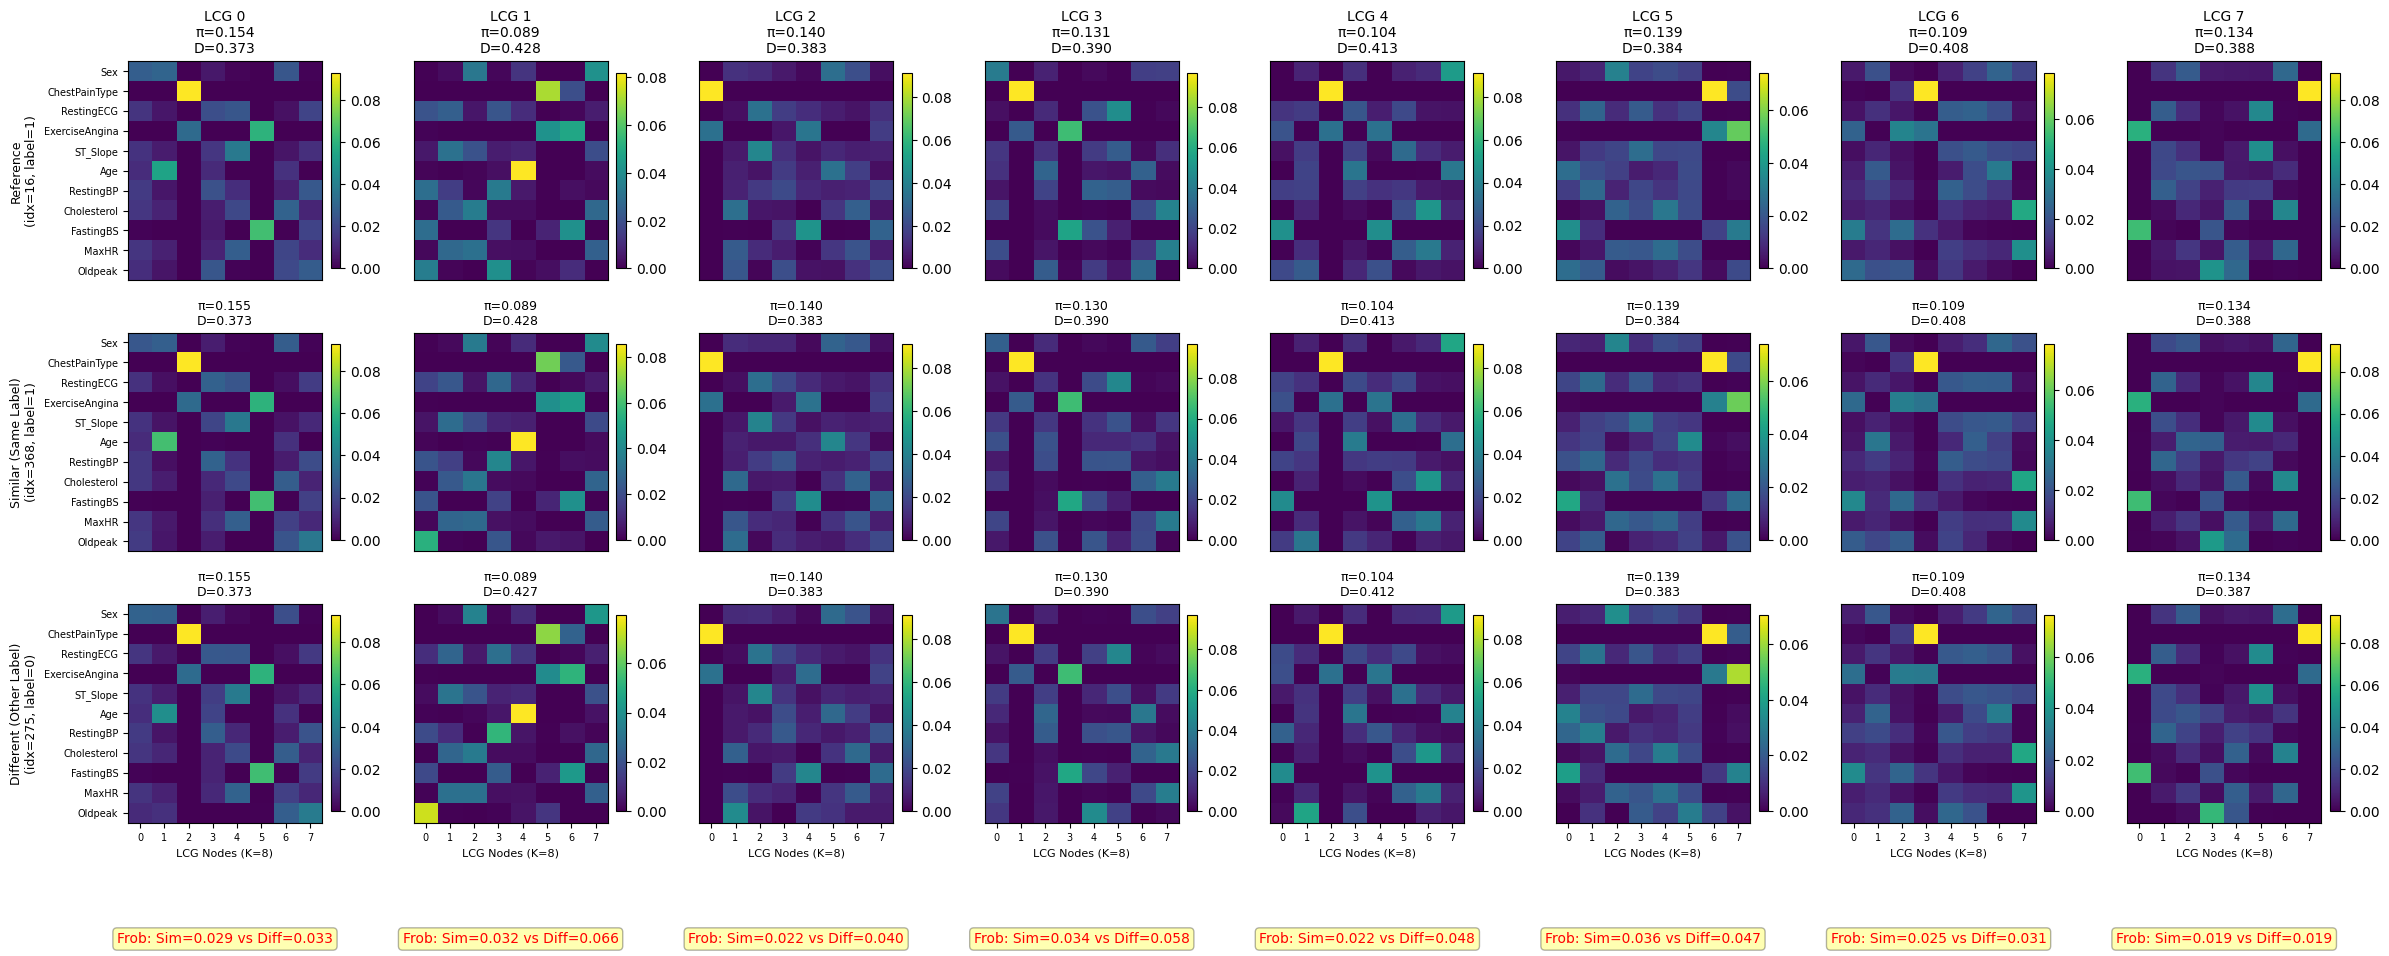

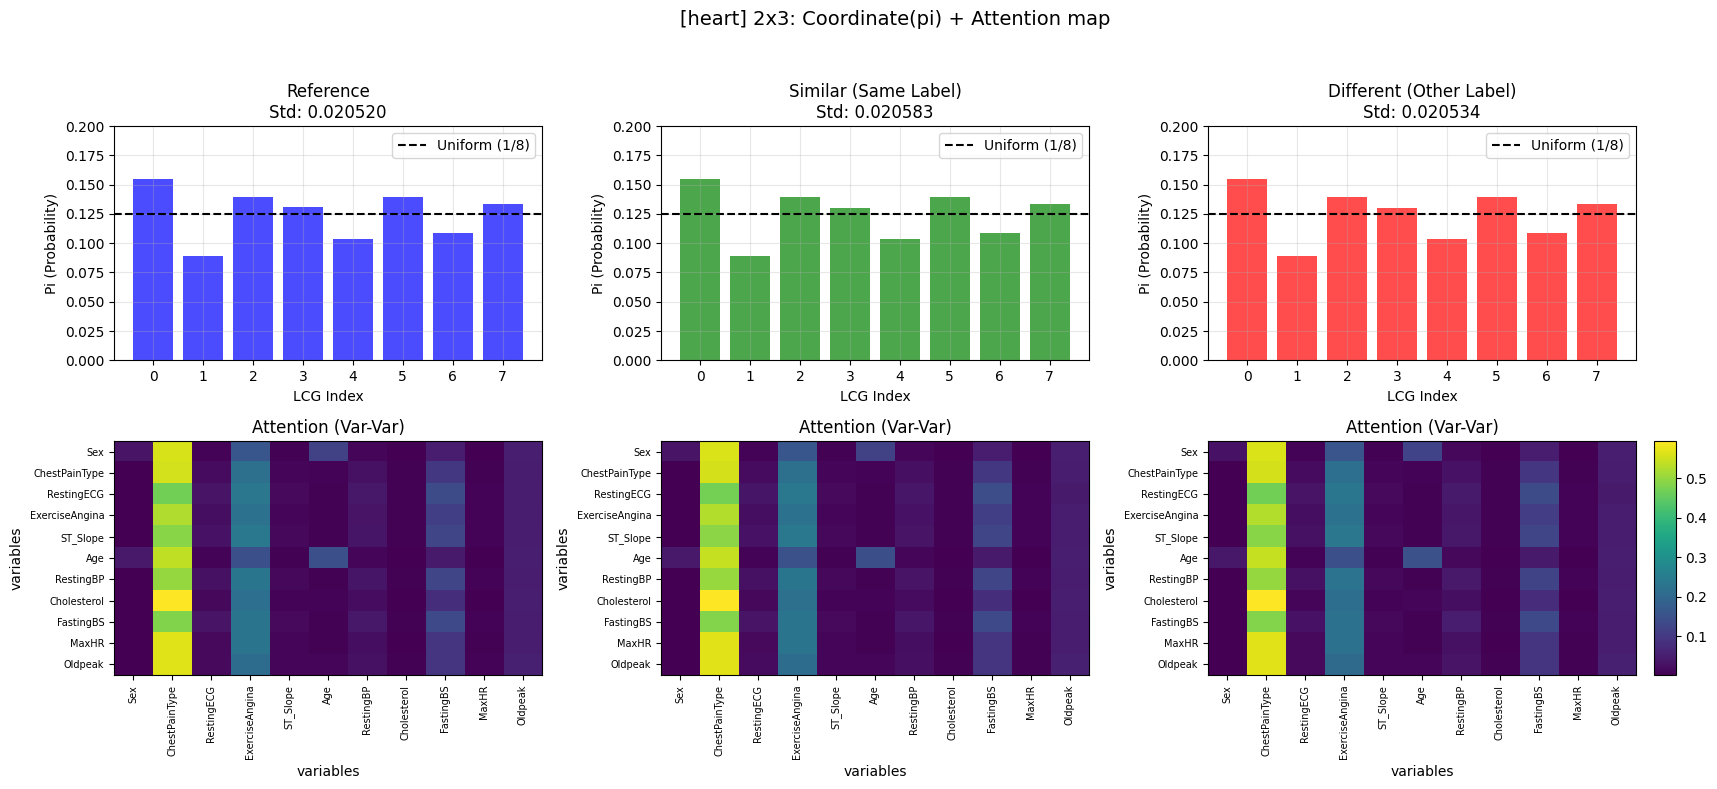

In [51]:

# =========================================================
# 실행 예시
# =========================================================
src = sources[0]
loader = loaders[src]
out = run_ref_sim_other_attention_viz(
    model=joint_model_pretrain,
    loader=loader,
    device=device,
    source_name=src,
    extract_feature_names_fn=extract_feature_names,
    reference_idx=16
)

## Coordinate Clustering

In [52]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from ot.batch import solve_gromov_batch

@torch.no_grad()
def _pi_batch(model, batch, device):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # ---- name/value gather (네 코드 규칙 그대로) ----
    name_embeddings, value_embeddings = [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    name  = torch.cat(name_embeddings, dim=1)   # [B, N, D]
    value = torch.cat(value_embeddings, dim=1)  # [B, N, D]
    B = value.size(0)

    # ---- basis forward to get last attention + node embeddings ----
    x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

    last_att = None
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
        last_att = att
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    # ---- var node embeddings / affinity (1 - att) ----
    node_emb = x_basis[:, 1:, :]                 # [B, N, D]
    var_att  = last_att[:, 0, 1:, 1:]            # [B, N, N] (head0)
    src_str  = (1.0 - var_att).contiguous()      # [B, N, N]
    src_feat = node_emb.contiguous()             # [B, N, D]

    # ---- LCG ----
    lcg_feat, lcg_struct = model.latent_graph()  # [M,K,D], [M,K,K]
    M, K, D = lcg_feat.shape
    N = src_feat.shape[1]

    # ---- expand to (B*M) ----
    src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B * M, N, D)
    src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B * M, N, N)
    lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B * M, K, D)
    lcg_str_exp  = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B * M, K, K)

    # ---- feature cost with tau ----
    dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
    scale_factor = dist_sq.max() + 1e-8
    dist_norm = dist_sq / scale_factor
    M_cost = 1.0 - torch.exp(-dist_norm / args.tau)

    a = torch.ones(B * M, N, device=device) / N
    b = torch.ones(B * M, K, device=device) / K

    alpha = model.graph_quantizer.alpha
    reg   = model.graph_quantizer.reg

    result = solve_gromov_batch(
        src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
        a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
    )

    d = result.value.reshape(B, M)  # [B,M]
    soft_tau = model.graph_quantizer.soft_tau
    pi = torch.softmax(-d / soft_tau, dim=1)     # [B,M]
    return pi.detach().cpu().numpy()

def pi_wrap(model, loaders_by_src, device, max_batches=200, per_src=False, title="pi_pop"):
    model.eval()

    def _collect_for_loader(loader):
        pis = []
        for bi, batch in enumerate(loader):
            if (max_batches is not None) and (bi >= max_batches):
                break
            pi = _pi_batch(model, batch, device)   # [B,M]
            pis.append(pi)
        return np.concatenate(pis, axis=0) if len(pis) > 0 else None  # [N,M]

    def _plot(pis, tag):
        M = pis.shape[1]
        mean_pi = pis.mean(axis=0)                 # [M]
        usage = np.bincount(pis.argmax(axis=1), minlength=M) / pis.shape[0]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].bar(range(M), mean_pi)
        axes[0].axhline(1.0/M, linestyle="--")
        axes[0].set_title(f"{tag} | mean(pi)")
        axes[0].set_xlabel("LCG index"); axes[0].set_ylabel("prob")

        axes[1].bar(range(M), usage)
        axes[1].axhline(1.0/M, linestyle="--")
        axes[1].set_title(f"{tag} | argmax usage")
        axes[1].set_xlabel("LCG index"); axes[1].set_ylabel("fraction")

        plt.tight_layout()
        plt.show()

    if per_src:
        out = {}
        for src, loader in loaders_by_src.items():
            pis = _collect_for_loader(loader)
            if pis is None:
                continue
            _plot(pis, f"{title}:{src} (n={pis.shape[0]})")
            out[src] = pis
        return out
    else:
        all_pis = []
        for src, loader in loaders_by_src.items():
            pis = _collect_for_loader(loader)
            if pis is None:
                continue
            all_pis.append(pis)
        pis = np.concatenate(all_pis, axis=0)
        _plot(pis, f"{title}:POOLED (n={pis.shape[0]})")
        return pis


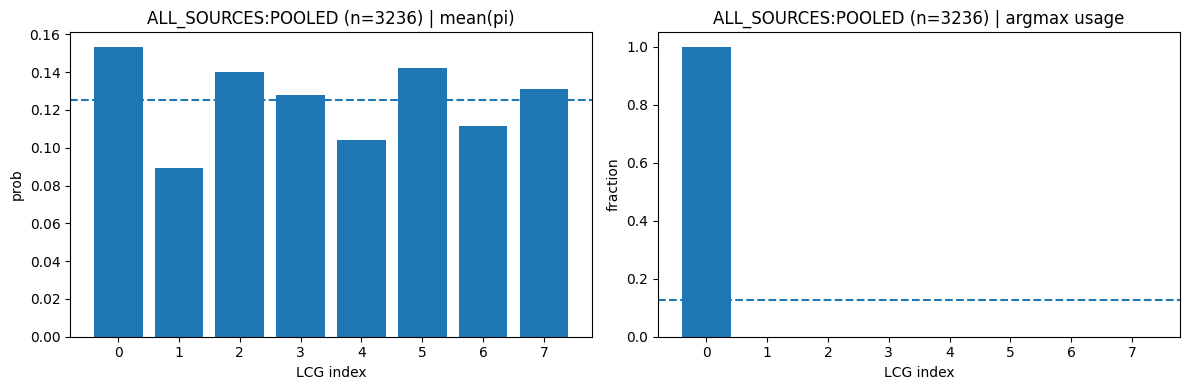

In [53]:
loaders_by_src = {src: loaders[src] for src in sources}  
pis = pi_wrap(model, loaders_by_src, device, max_batches=None, per_src=False, title="ALL_SOURCES")


In [54]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from ot.batch import solve_gromov_batch

@torch.no_grad()
def _d_pi_batch(model, batch, device):
    model.eval()
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # ---- name/value gather (네 규칙 최대한 유지) ----
    name_embeddings, value_embeddings = [], []

    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings']):
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])

    # num 쪽 키는 환경마다 다르길래 안전하게 처리
    if ('num_name_embeddings' in batch) and ('num_prompt_embeddings' in batch):
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    name  = torch.cat(name_embeddings, dim=1)   # [B, N, D]
    value = torch.cat(value_embeddings, dim=1)  # [B, N, D]
    B = value.size(0)

    # ---- basis forward to get last attention + node embeddings ----
    x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

    last_att = None
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
        last_att = att
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    # ---- src_feat / src_str ----
    src_feat = x_basis[:, 1:, :].contiguous()           # [B, N, D]
    var_att  = last_att[:, 0, 1:, 1:].contiguous()      # [B, N, N] (head0)
    src_str  = (1.0 - var_att).contiguous()             # [B, N, N]

    # ---- LCG ----
    lcg_feat, lcg_str = model.latent_graph()            # [M,K,D], [M,K,K]
    M, K, D = lcg_feat.shape
    N = src_feat.shape[1]

    # ---- expand to (B*M) ----
    src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B * M, N, D)
    src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B * M, N, N)
    lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B * M, K, D)
    lcg_str_exp  = lcg_str.unsqueeze(0).expand(B, M, K, K).reshape(B * M, K, K)

    # ---- Feature cost: (네 compute_fgw 방식과 맞추기: max scaling + exp) ----
    dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
    scale_factor = dist_sq.max() + 1e-8
    dist_norm = dist_sq / scale_factor

    tau = float(model.graph_quantizer.tau)
    M_cost = 1.0 - torch.exp(-dist_norm / (tau + 1e-12))

    a = torch.ones(B * M, N, device=device) / N
    b = torch.ones(B * M, K, device=device) / K

    alpha = float(model.graph_quantizer.alpha)
    reg   = float(model.graph_quantizer.reg)

    result = solve_gromov_batch(
        src_str_exp, lcg_str_exp, M=M_cost,
        alpha=alpha, reg=reg, a=a, b=b,
        max_iter=10, tol=1e-3, grad='envelope'
    )

    d = result.value.reshape(B, M)                      # [B, M]
    soft_tau = float(model.graph_quantizer.soft_tau)
    pi = torch.softmax(-d / (soft_tau + 1e-12), dim=1)  # [B, M]

    return d.detach().cpu().numpy(), pi.detach().cpu().numpy()


def collect_d_pi(model, loaders_by_src, device, max_batches=50, pooled=True):
    d_all, pi_all = [], []
    for src, loader in loaders_by_src.items():
        for bi, batch in enumerate(loader):
            if (max_batches is not None) and (bi >= max_batches):
                break
            d, pi = _d_pi_batch(model, batch, device)
            d_all.append(d); pi_all.append(pi)

    d_all  = np.concatenate(d_all, axis=0)   # [S, M]
    pi_all = np.concatenate(pi_all, axis=0)  # [S, M]
    return d_all, pi_all


samples: 3236 M: 8

mean(pi): [0.1534 0.0891 0.14   0.128  0.1042 0.1424 0.1117 0.1312]
usage(argmax pi): [1. 0. 0. 0. 0. 0. 0. 0.]

mean(d) per LCG: [0.151231 0.205607 0.160341 0.169287 0.189865 0.158655 0.182897 0.166872]
best LCGs by mean(d): [0 5 2 7]  (smaller is better)

Gap(d2-d1): mean= 0.0073946635 median= 0.0072339326 p90= 0.009008444845676422 min= 0.0030051768 max= 0.012057781

Gap(pi_top1 - pi_top2): mean= 0.010930353 median= 0.010699376 p90= 0.013271532952785492


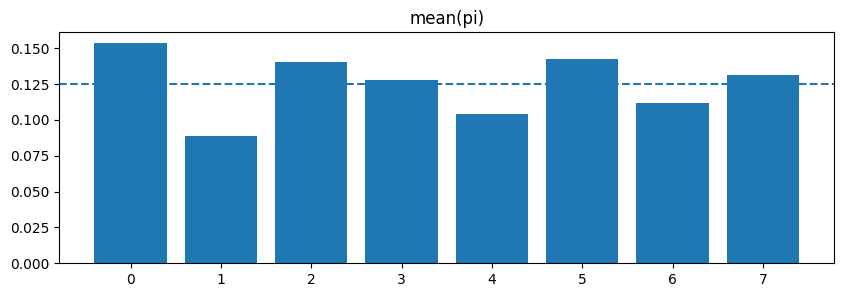

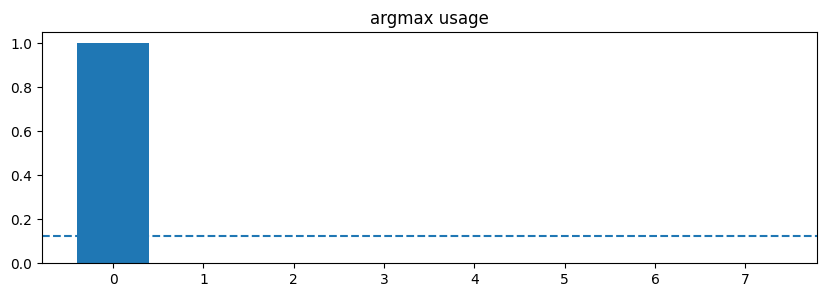

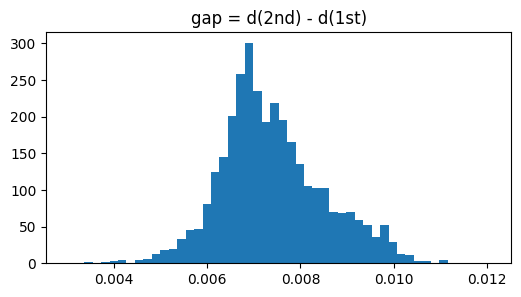

In [55]:
# 1) 뽑기
d_all, pi_all = collect_d_pi(model, loaders_by_src, device, max_batches=50)

M = pi_all.shape[1]
S = pi_all.shape[0]
print("samples:", S, "M:", M)

# 2) mean(pi) vs argmax usage
mean_pi = pi_all.mean(axis=0)
usage_pi = np.bincount(pi_all.argmax(axis=1), minlength=M) / S

print("\nmean(pi):", np.round(mean_pi, 4))
print("usage(argmax pi):", np.round(usage_pi, 4))

# 3) 핵심: d에서 이미 3/4가 '항상 1등'인지?
d_mean = d_all.mean(axis=0)
rank = np.argsort(d_mean)  # 작은 d가 더 좋음
print("\nmean(d) per LCG:", np.round(d_mean, 6))
print("best LCGs by mean(d):", rank[:4], " (smaller is better)")

# 4) 동률(미세차)인지 확인: gap = d2 - d1
d_sorted = np.sort(d_all, axis=1)
gap = d_sorted[:, 1] - d_sorted[:, 0]
print("\nGap(d2-d1): mean=", gap.mean(), "median=", np.median(gap),
      "p90=", np.quantile(gap, 0.9), "min=", gap.min(), "max=", gap.max())

# 5) pi 자체도 거의 동률인지: (top1-top2)
top2 = np.partition(pi_all, -2, axis=1)[:, -2:]  # unsorted 2 largest
pi_top1 = top2.max(axis=1)
pi_top2 = top2.min(axis=1)
print("\nGap(pi_top1 - pi_top2): mean=", (pi_top1 - pi_top2).mean(),
      "median=", np.median(pi_top1 - pi_top2),
      "p90=", np.quantile(pi_top1 - pi_top2, 0.9))

# 6) 간단 플롯
plt.figure(figsize=(10,3))
plt.bar(np.arange(M), mean_pi)
plt.axhline(1.0/M, linestyle="--")
plt.title("mean(pi)")
plt.show()

plt.figure(figsize=(10,3))
plt.bar(np.arange(M), usage_pi)
plt.axhline(1.0/M, linestyle="--")
plt.title("argmax usage")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(gap, bins=50)
plt.title("gap = d(2nd) - d(1st)")
plt.show()



[ALL_SOURCES:POOLED] N=3236, M=8
  H_sample_norm: mean=0.9927  (goal: LOW)
  H_batch_norm : 0.9931            (goal: HIGH)
  top1 prob    : mean=0.1561,  median=0.1549
  margin(top1-top2): mean=0.0084, median=0.0078
  mean(pi) deviation from uniform (L1): 0.1412
  argmax usage deviation from uniform (L1): 1.6221
  top4 coverage: min=0.0000, mean=0.5000, max=0.9997


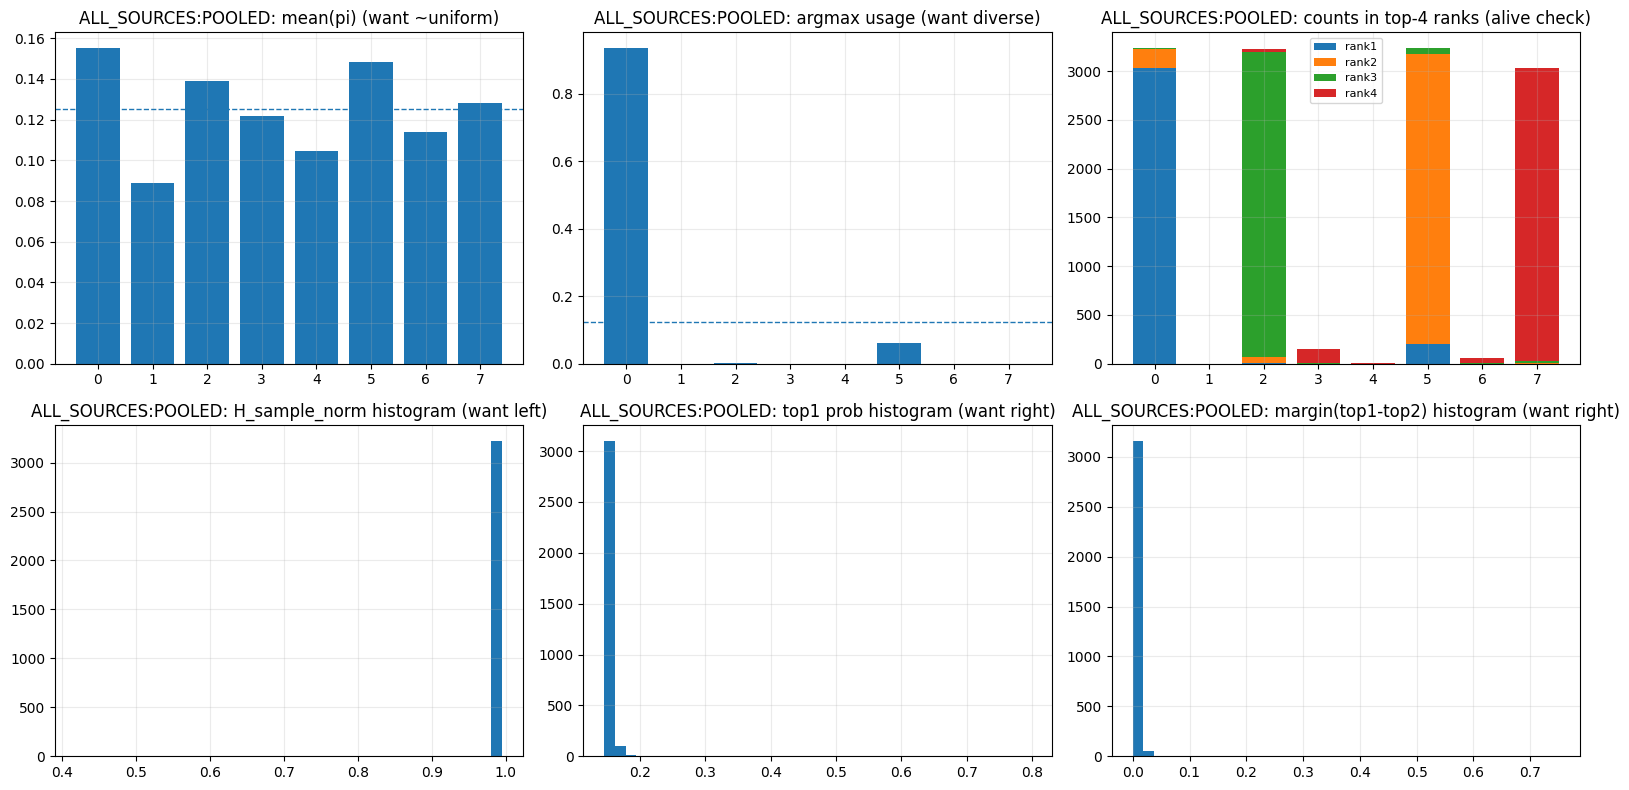


[SRC=heart] N=918, M=8
  H_sample_norm: mean=0.9924  (goal: LOW)
  H_batch_norm : 0.9932            (goal: HIGH)
  top1 prob    : mean=0.1573,  median=0.1554
  margin(top1-top2): mean=0.0090, median=0.0072
  mean(pi) deviation from uniform (L1): 0.1417
  argmax usage deviation from uniform (L1): 1.6236
  top4 coverage: min=0.0000, mean=0.5000, max=1.0000

[SRC=Cardiovascular_Disease_Dataset] N=1000, M=8
  H_sample_norm: mean=0.9930  (goal: LOW)
  H_batch_norm : 0.9930            (goal: HIGH)
  top1 prob    : mean=0.1546,  median=0.1545
  margin(top1-top2): mean=0.0067, median=0.0072
  mean(pi) deviation from uniform (L1): 0.1425
  argmax usage deviation from uniform (L1): 1.6360
  top4 coverage: min=0.0000, mean=0.5000, max=1.0000

[SRC=Heart_disease_statlog] N=270, M=8
  H_sample_norm: mean=0.9932  (goal: LOW)
  H_batch_norm : 0.9932            (goal: HIGH)
  top1 prob    : mean=0.1547,  median=0.1544
  margin(top1-top2): mean=0.0086, median=0.0084
  mean(pi) deviation from uniform (

In [56]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# 1) collect pi (all samples)
# -----------------------------
@torch.no_grad()
def collect_all_pi(model, loaders, device, max_batches_per_src=None):
    model.eval()
    out = {}
    all_pi = []

    for src, loader in loaders.items():
        pis = []
        for bi, batch in enumerate(loader):
            if max_batches_per_src is not None and bi >= max_batches_per_src:
                break
            batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            _ = model.predict(batch_t, return_all=True)
            pi = model.graph_quantizer.last_pi  # [B,M]
            if pi is None:
                raise RuntimeError("last_pi is None. args.use_lcg=True & predict(return_all=True) path 확인")

            pis.append(pi.detach().cpu().numpy())

        if len(pis) == 0:
            continue
        pis = np.concatenate(pis, axis=0)  # [N_src, M]
        out[src] = pis
        all_pi.append(pis)

    all_pi = np.concatenate(all_pi, axis=0) if len(all_pi) else None
    return out, all_pi


# -----------------------------
# 2) diagnostics
# -----------------------------
def _entropy_rows(P, eps=1e-12):
    P = np.clip(P, eps, 1.0)
    return -(P * np.log(P)).sum(axis=1)  # [N]

def _top1_top2(P):
    # returns top1 prob, top2 prob, margin
    part = np.partition(P, -2, axis=1)          # last two are top2 (unordered)
    top2 = part[:, -2]
    top1 = part[:, -1]
    # ensure top1>=top2 (partition doesn't guarantee order between last two)
    t1 = np.maximum(top1, top2)
    t2 = np.minimum(top1, top2)
    return t1, t2, (t1 - t2)

def _rank_hist(P, max_rank=4):
    # counts: for each m, how often it appears in rank r (1..max_rank)
    # rank 1 = argmax
    N, M = P.shape
    order = np.argsort(-P, axis=1)  # descending
    counts = np.zeros((max_rank, M), dtype=np.int64)
    for r in range(max_rank):
        idx_m = order[:, r]
        counts[r] = np.bincount(idx_m, minlength=M)
    return counts  # [max_rank, M]

def diagnose_pi(P, tag="POOLED", show=True):
    P = np.asarray(P)
    N, M = P.shape
    H_max = np.log(M)

    # --- entropies ---
    Hs = _entropy_rows(P)            # [N]
    Hs_norm = Hs / H_max
    pibar = P.mean(axis=0)
    Hb = -(np.clip(pibar, 1e-12, 1.0) * np.log(np.clip(pibar, 1e-12, 1.0))).sum()
    Hb_norm = Hb / H_max

    # --- usage / sharpness proxies ---
    argmax = P.argmax(axis=1)
    usage = np.bincount(argmax, minlength=M) / N  # [M]
    mean_pi = pibar
    t1, t2, margin = _top1_top2(P)

    # --- "dead but alive" check: rank counts ---
    rank_counts = _rank_hist(P, max_rank=4)  # [4, M] ranks 1..4

    # --- prints ---
    print(f"\n[{tag}] N={N}, M={M}")
    print(f"  H_sample_norm: mean={Hs_norm.mean():.4f}  (goal: LOW)")
    print(f"  H_batch_norm : {Hb_norm:.4f}            (goal: HIGH)")
    print(f"  top1 prob    : mean={t1.mean():.4f},  median={np.median(t1):.4f}")
    print(f"  margin(top1-top2): mean={margin.mean():.4f}, median={np.median(margin):.4f}")
    print(f"  mean(pi) deviation from uniform (L1): {np.abs(mean_pi - 1.0/M).sum():.4f}")
    print(f"  argmax usage deviation from uniform (L1): {np.abs(usage - 1.0/M).sum():.4f}")

    # rank-based "alive" quick view
    # 각 m이 rank<=4에 들어오는 비율
    top4_frac = rank_counts.sum(axis=0) / N
    print(f"  top4 coverage: min={top4_frac.min():.4f}, mean={top4_frac.mean():.4f}, max={top4_frac.max():.4f}")

    if not show:
        return

    # ---------------- plots ----------------
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # (1) mean(pi) + argmax usage
    axes[0,0].bar(np.arange(M), mean_pi)
    axes[0,0].axhline(1.0/M, linestyle="--", linewidth=1)
    axes[0,0].set_title(f"{tag}: mean(pi) (want ~uniform)")
    axes[0,0].grid(True, alpha=0.25)

    axes[0,1].bar(np.arange(M), usage)
    axes[0,1].axhline(1.0/M, linestyle="--", linewidth=1)
    axes[0,1].set_title(f"{tag}: argmax usage (want diverse)")
    axes[0,1].grid(True, alpha=0.25)

    # (2) rank1~4 counts stacked (dead-but-alive 체크 핵심)
    # rank1=argmax, rank2, rank3, rank4
    bottoms = np.zeros(M, dtype=np.int64)
    labels = ["rank1", "rank2", "rank3", "rank4"]
    for r in range(4):
        axes[0,2].bar(np.arange(M), rank_counts[r], bottom=bottoms, label=labels[r])
        bottoms += rank_counts[r]
    axes[0,2].set_title(f"{tag}: counts in top-4 ranks (alive check)")
    axes[0,2].grid(True, alpha=0.25)
    axes[0,2].legend(fontsize=8, frameon=True)

    # (3) hist: sample entropy
    axes[1,0].hist(Hs_norm, bins=40)
    axes[1,0].set_title(f"{tag}: H_sample_norm histogram (want left)")
    axes[1,0].grid(True, alpha=0.25)

    # (4) hist: top1 prob
    axes[1,1].hist(t1, bins=40)
    axes[1,1].set_title(f"{tag}: top1 prob histogram (want right)")
    axes[1,1].grid(True, alpha=0.25)

    # (5) hist: margin
    axes[1,2].hist(margin, bins=40)
    axes[1,2].set_title(f"{tag}: margin(top1-top2) histogram (want right)")
    axes[1,2].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


# -----------------------------
# 3) run (pooled + per source)
# -----------------------------
pi_by_src, pi_all = collect_all_pi(model, loaders, device, max_batches_per_src=None)

diagnose_pi(pi_all, tag="ALL_SOURCES:POOLED", show=True)

for src, P in pi_by_src.items():
    diagnose_pi(P, tag=f"SRC={src}", show=False)  # source별은 출력만, 그림은 원하면 True로


- H_sample norm histogram (want left)
    - 각 샘플의 entropy H(pi)를 최대 엔트로피 log M으로 나누어 normalize
    - 0에 가까우면 거의 one hot이고 
    - 1에 가까우면 uniform 
    - 현재 막대가 0.98 ~ 1.0 에 몰려 있어서 sample entropy 낮게와는 정반대

- top1 prob histogram (want right)
    - 각 샘플에서 max_m pi_m 가장 큰 값의 분포 
    - flat이면 top 1이 1/M

- top1 - top2 histogram 
    - 각 샘플에서 (1등 확률 - 2등 확률) 차이 
    - 결정의 확신도 
    - 샤프하면 top1이 크고, top2가 작아서 margin이 크게 나옴 
    - 애매하면 top 1 ~ top 2여서 margin이 0 근처 
    - 현재 0 ~ 0.03 근처여서 top1과 top2가 거의 비슷함.


[ALL_SOURCES:POOLED] N=3236, M=8
mu gap(worst-best) = 0.054376  | best m=0, worst m=1
  m0: mu=0.151231  std=0.031755  [min,max]=[0.075101,0.264407]
  m5: mu=0.158655  std=0.031488  [min,max]=[0.084678,0.272095]
  m2: mu=0.160341  std=0.031860  [min,max]=[0.085062,0.273723]
  m7: mu=0.166872  std=0.031864  [min,max]=[0.090050,0.279953]
  m3: mu=0.169287  std=0.032177  [min,max]=[0.091599,0.283674]
  m6: mu=0.182897  std=0.031727  [min,max]=[0.109040,0.297734]
  m4: mu=0.189865  std=0.031855  [min,max]=[0.114067,0.303809]
  m1: mu=0.205607  std=0.031959  [min,max]=[0.128783,0.320779]


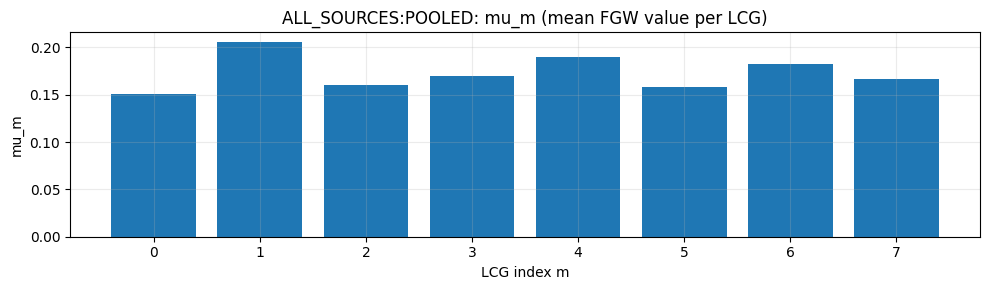

In [57]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from ot.batch import solve_gromov_batch

@torch.no_grad()
def collect_d_commit(model, loaders_by_src, device, max_batches=200, per_src=False):
    """
    각 샘플에 대해 d_commit[b,m] (FGW value) 를 모아서
      - pooled: [N_total, M]
      - per_src: dict[src] -> [N_src, M]
    를 반환.
    """
    model.eval()

    def _one_loader(loader):
        d_list = []
        for bi, batch in enumerate(loader):
            if (max_batches is not None) and (bi >= max_batches):
                break

            batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            # ---- name/value gather (네 규칙 그대로) ----
            name_embeddings, value_embeddings = [], []
            if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
                name_embeddings.append(batch['cat_name_embeddings'])
                value_embeddings.append(batch['cat_value_embeddings'])
            if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
                name_embeddings.append(batch['num_name_embeddings'])
                value_embeddings.append(batch['num_prompt_embeddings'])

            name  = torch.cat(name_embeddings, dim=1)   # [B,N,D]
            value = torch.cat(value_embeddings, dim=1)  # [B,N,D]
            B, N, D = value.shape

            # ---- basis forward (last_att 확보) ----
            x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
            last_att = None
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
                last_att = att
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

            # ---- src feat/struct (Var-Var, head0) ----
            src_feat = x_basis[:, 1:, :].contiguous()            # [B,N,D]
            var_att  = last_att[:, 0, 1:, 1:]                    # [B,N,N]
            src_str  = (1.0 - var_att).contiguous()              # [B,N,N]

            # ---- LCG ----
            lcg_feat, lcg_struct = model.latent_graph()          # [M,K,D], [M,K,K]
            M, K, _ = lcg_feat.shape

            # ---- expand to (B*M) ----
            src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
            src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
            lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
            lcg_str_exp  = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)

            # ---- feature cost: (GraphQuantizer.compute_fgw 와 동일 스케일링) ----
            dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
            scale_factor = dist_sq.max() + 1e-8
            dist_norm = dist_sq / scale_factor

            tau = float(model.graph_quantizer.tau)
            M_cost = 1.0 - torch.exp(-dist_norm / tau)

            a = torch.ones(B*M, N, device=device) / N
            b = torch.ones(B*M, K, device=device) / K
            alpha = float(model.graph_quantizer.alpha)
            reg   = float(model.graph_quantizer.reg)

            result = solve_gromov_batch(
                src_str_exp, lcg_str_exp, M=M_cost,
                alpha=alpha, reg=reg, a=a, b=b,
                max_iter=10, tol=1e-3, grad='envelope'
            )

            d = result.value.reshape(B, M)  # [B,M]
            d_list.append(d.detach().cpu().numpy())

        if len(d_list) == 0:
            return None
        return np.concatenate(d_list, axis=0)  # [N_loader, M]

    if per_src:
        out = {}
        for src, loader in loaders_by_src.items():
            d = _one_loader(loader)
            if d is not None:
                out[src] = d
        return out
    else:
        all_d = []
        for src, loader in loaders_by_src.items():
            d = _one_loader(loader)
            if d is not None:
                all_d.append(d)
        if len(all_d) == 0:
            return None
        return np.concatenate(all_d, axis=0)  # [N_total, M]


def report_mu_m(d, title="POOLED"):
    """
    d: [N,M]
    """
    d = np.asarray(d)
    mu  = d.mean(axis=0)
    std = d.std(axis=0)
    mn  = d.min(axis=0)
    mx  = d.max(axis=0)

    order = np.argsort(mu)
    best, worst = order[0], order[-1]
    gap = mu[worst] - mu[best]

    print(f"\n[{title}] N={d.shape[0]}, M={d.shape[1]}")
    print(f"mu gap(worst-best) = {gap:.6f}  | best m={best}, worst m={worst}")
    for m in order:
        print(f"  m{m}: mu={mu[m]:.6f}  std={std[m]:.6f}  [min,max]=[{mn[m]:.6f},{mx[m]:.6f}]")

    # 간단 시각화
    plt.figure(figsize=(10,3))
    plt.bar(np.arange(len(mu)), mu)
    plt.title(f"{title}: mu_m (mean FGW value per LCG)")
    plt.xlabel("LCG index m"); plt.ylabel("mu_m")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


# =========================
# 사용 예시
# =========================
# 1) 전체 pooled로 확인
d_all = collect_d_commit(model, loaders, device, max_batches=50, per_src=False)
report_mu_m(d_all, title="ALL_SOURCES:POOLED")

# 2) source별로도 보고 싶으면
# d_by_src = collect_d_commit(model, loaders, device, max_batches=50, per_src=True)
# for src, d in d_by_src.items():
#     report_mu_m(d, title=f"SRC={src}")


winner usage: [1. 0. 0. 0. 0. 0. 0. 0.] sum= 1.0
gap stats: mean 0.0073946635 median 0.0072339326 p90 0.009008444845676422


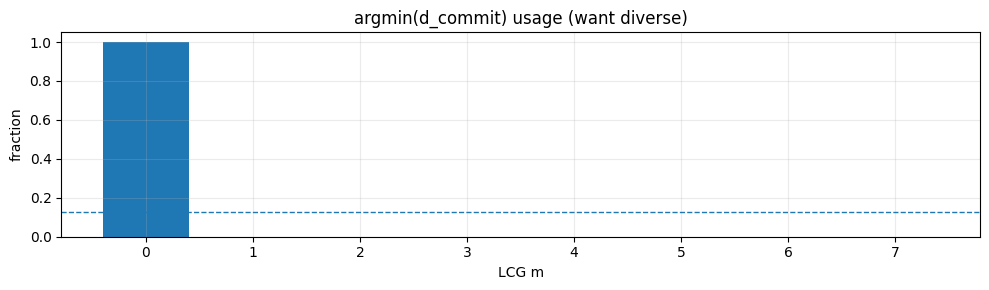

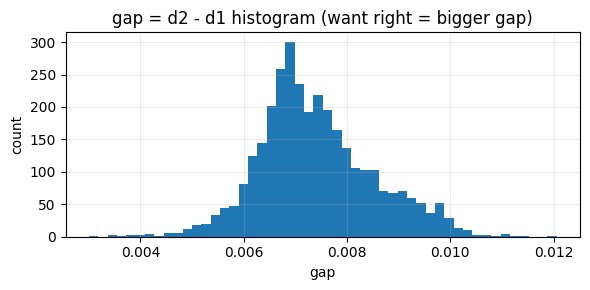

In [58]:
d = d_all

# 1) per-sample best/2nd-best gap (confidence in d-space)
d_sort = np.sort(d, axis=1)         # ascending: smaller is better
gap = d_sort[:, 1] - d_sort[:, 0]   # d2 - d1  (bigger => clearer winner)

# 2) argmin usage (d-space winner diversity)
winner = np.argmin(d, axis=1)
usage = np.bincount(winner, minlength=d.shape[1]) / d.shape[0]

print("winner usage:", usage, "sum=", usage.sum())
print("gap stats: mean", gap.mean(), "median", np.median(gap), "p90", np.quantile(gap, 0.9))

plt.figure(figsize=(10,3))
plt.bar(np.arange(d.shape[1]), usage)
plt.axhline(1.0/d.shape[1], linestyle="--", linewidth=1)
plt.title("argmin(d_commit) usage (want diverse)")
plt.xlabel("LCG m"); plt.ylabel("fraction")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.hist(gap, bins=50)
plt.title("gap = d2 - d1 histogram (want right = bigger gap)")
plt.xlabel("gap"); plt.ylabel("count")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

< 결과 >
- Top 1 과 Top 2의 차이가 거의 없다면 이들의 cost 차이가 없음을 의미 

In [59]:
import torch
import math
from ot.batch import solve_gromov_batch

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# 0) 설정
# -----------------------------
B = 4
M = 6
N = 8
K = 8
D = 768

alpha = 0.5
reg = 0.05
soft_tau = 0.05

# "거리 차이를 확확" 만들기 위한 세기
close_noise = 0.05    # 정답 후보는 src와 거의 같게
far_offset  = 12.0    # 오답 후보는 큰 offset으로 멀게
far_noise   = 1.0

# -----------------------------
# 1) src_feat 만들기 (분산을 크게: dist_sq 크게 나오도록)
# -----------------------------
src_feat = (torch.randn(B, N, D, device=device) * 3.0)

# -----------------------------
# 2) tgt_feat 만들기: 각 b마다 정답 후보 하나는 가깝게, 나머지는 멀게
# -----------------------------
tgt_feat = torch.empty(B, M, K, D, device=device)

# 각 샘플 b의 "정답 LCG index"를 하나 정해두기
m_star = torch.randint(low=0, high=M, size=(B,), device=device)

for b in range(B):
    for m in range(M):
        if m == int(m_star[b]):
            # src를 약간 섞어서 "가깝게" (node permutation 영향 줄이려고 동일 N=K 가정)
            tgt_feat[b, m] = src_feat[b] + close_noise * torch.randn(K, D, device=device)
        else:
            # "멀게": 큰 offset + noise
            tgt_feat[b, m] = (torch.randn(K, D, device=device) * far_noise) + far_offset

# -----------------------------
# 3) attention-map 기반 구조 cost: 1 - attn (너 흐름 그대로)
# -----------------------------
def attn_cost_from_feat(feat, proj_dim=64):
    D_in = feat.shape[-1]
    wq = torch.randn(D_in, proj_dim, device=feat.device) / math.sqrt(D_in)
    wk = torch.randn(D_in, proj_dim, device=feat.device) / math.sqrt(D_in)
    Q = feat @ wq
    Kmat = feat @ wk
    scores = (Q @ Kmat.transpose(-2, -1)) / math.sqrt(proj_dim)
    attn = torch.softmax(scores, dim=-1)
    return 1.0 - attn  # cost

src_str = attn_cost_from_feat(src_feat)  # [B,N,N]
tgt_str = attn_cost_from_feat(tgt_feat.reshape(B*M, K, D)).reshape(B, M, K, K)

# -----------------------------
# 4) FGW 입력 형태로 flatten
# -----------------------------
src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
tgt_feat_exp = tgt_feat.reshape(B*M, K, D)
tgt_str_exp  = tgt_str.reshape(B*M, K, K)

a = torch.ones(B*M, N, device=device) / N
b = torch.ones(B*M, K, device=device) / K

# -----------------------------
# 5) "진짜 거리 차이 크게 만들었는지" 먼저 확인
# -----------------------------
dist_sq = torch.cdist(src_feat_exp, tgt_feat_exp, p=2) ** 2          # [B*M,N,K]
dist_norm = dist_sq / float(D)

# 후보별로 dist_norm의 "평균 cost"를 뽑아보기(간단 진단)
d_feat_only = dist_norm.mean(dim=(1,2)).reshape(B, M)                # [B,M]

print("\n[FEATURE-ONLY DIST CHECK] (mean over N,K)")
for bidx in range(B):
    vals = d_feat_only[bidx].detach().cpu()
    top2 = torch.topk(-vals, k=2).values  # 작은 거리일수록 좋으니 -vals의 top
    gap = (top2[0] - top2[1]).item()
    print(f"  b={bidx} | m*={int(m_star[bidx])} | d_feat={vals.numpy().round(3)} | gap(top1-top2)={gap:.3f}")

# -----------------------------
# 6) cost 구성: RAW vs (CF+CS mean-scaling)
# -----------------------------
# RAW feature cost
M_feat_raw = dist_norm

# mean-scaling feature cost (CF)
sf = dist_norm.detach().mean() + 1e-8
M_feat_scaled = dist_norm / sf

# struct mean-scaling (CS)  -- src/tgt 각각
ss = src_str_exp.detach().mean() + 1e-8
st = tgt_str_exp.detach().mean() + 1e-8
src_str_scaled = src_str_exp / ss
tgt_str_scaled = tgt_str_exp / st

def run_fgw(src_s, tgt_s, M_cost, tag):
    out = solve_gromov_batch(
        src_s, tgt_s, M=M_cost, alpha=alpha, reg=reg, a=a, b=b,
        max_iter=10, tol=1e-3, grad="envelope"
    )
    Tplan = out.plan.detach()
    val = out.value.detach()

    feat_term = (M_cost * Tplan).sum(dim=(1,2)).mean().item()
    total_val = val.mean().item()
    struct_term = (total_val - (1 - alpha) * feat_term) / (alpha + 1e-9)
    ratio = feat_term / (struct_term + 1e-9)

    print(f"\n[{tag}]")
    print(f"  M_cost mean={M_cost.mean().item():.4f}, std={M_cost.std().item():.4f}")
    print(f"  src_str mean={src_s.mean().item():.4f}, tgt_str mean={tgt_s.mean().item():.4f}")
    print(f"  FGW value mean={total_val:.6f}")
    print(f"  Feat term={feat_term:.6f} | Struct term={struct_term:.6f} | Ratio={ratio:.3f}")
    return out

out_raw = run_fgw(src_str_exp, tgt_str_exp, M_feat_raw, "RAW (no scaling)")
out_scaled = run_fgw(src_str_scaled, tgt_str_scaled, M_feat_scaled, "SCALED (CF+CS mean-scaling)")

# -----------------------------
# 7) pi 확인 + 정답 m*가 top으로 오는지 확인
# -----------------------------
d_raw = out_raw.value.reshape(B, M)
d_scl = out_scaled.value.reshape(B, M)

pi_raw = torch.softmax(-d_raw / soft_tau, dim=1)
pi_scl = torch.softmax(-d_scl / soft_tau, dim=1)

print("\n[PI + ARGMIN CHECK]")
for bidx in range(B):
    raw_pick = int(torch.argmin(d_raw[bidx]).item())
    scl_pick = int(torch.argmin(d_scl[bidx]).item())
    print(f"  b={bidx} | m*={int(m_star[bidx])} | raw_pick={raw_pick} | scaled_pick={scl_pick}")
    print(f"    raw   pi: {pi_raw[bidx].detach().cpu().numpy().round(4)}")
    print(f"    scaled pi: {pi_scl[bidx].detach().cpu().numpy().round(4)}")



[FEATURE-ONLY DIST CHECK] (mean over N,K)
  b=0 | m*=4 | d_feat=[154.74  154.095 154.26  154.38   15.581 153.919] | gap(top1-top2)=138.338
  b=1 | m*=4 | d_feat=[154.969 154.972 154.462 154.939  15.847 154.617] | gap(top1-top2)=138.616
  b=2 | m*=3 | d_feat=[154.94  155.532 154.597  15.968 155.438 155.598] | gap(top1-top2)=138.629
  b=3 | m*=0 | d_feat=[ 15.48  154.609 155.31  154.964 155.497 154.676] | gap(top1-top2)=139.130

[RAW (no scaling)]
  M_cost mean=131.6411, std=51.9689
  src_str mean=0.8750, tgt_str mean=0.8750
  FGW value mean=64.484306
  Feat term=128.808395 | Struct term=0.160217 | Ratio=803.961

[SCALED (CF+CS mean-scaling)]
  M_cost mean=1.0000, std=0.3948
  src_str mean=1.0000, tgt_str mean=1.0000
  FGW value mean=0.580554
  Feat term=0.987328 | Struct term=0.173781 | Ratio=5.681

[PI + ARGMIN CHECK]
  b=0 | m*=4 | raw_pick=4 | scaled_pick=4
    raw   pi: [0. 0. 0. 0. 1. 0.]
    scaled pi: [0. 0. 0. 0. 1. 0.]
  b=1 | m*=4 | raw_pick=4 | scaled_pick=4
    raw   pi: [0